# NLP-Based Poem Analyzer

## 📌 Problem Statement
Poetry analysis is a complex task that involves understanding the sentiment, themes, and structure of a poem. Traditional methods rely on human interpretation, which can be subjective. This project leverages **Natural Language Processing (NLP)** techniques to analyze poetry computationally, providing insights into sentiment, themes, and structure.

## 📜 Objectives
- Preprocess and clean poem text for analysis
- Extract key features such as **sentiment, themes, and rhyme schemes**
- Utilize **machine learning models** for sentiment classification and theme detection
- Evaluate and optimize the performance of the models

## 📑 Table of Contents
1. **Introduction**  
2. **Dataset Overview**  
3. **Exploratory Data Analysis (EDA)**  
4. **Text Preprocessing**  
5. **Feature Engineering**  
6. **Model Selection & Training**  
7. **Evaluation Metrics**  
8. **Results & Analysis**  
9. **Future Improvements**  
10. **Conclusion**  





## 📖 Introduction
### 1️⃣ Project Overview
Poetry analysis is a challenging task due to its subjective nature, use of figurative language, and varying structures. This project aims to analyze poems using **Natural Language Processing (NLP)** techniques, providing insights into sentiment, themes, and structure.

### 2️⃣ Motivation & Importance
- Automating literary analysis for students and researchers
- Helping AI understand artistic and creative expressions
- Enhancing digital tools for poetry recommendation and evaluation

### 3️⃣ Scope of the Project
This project will focus on:
- **Sentiment Analysis**: Identifying emotions in poems (positive, negative, neutral)
- **Theme Classification**: Detecting central themes (love, nature, death, etc.)
- **Rhyme Scheme Recognition**: Identifying rhyming patterns
- **Poetic Structure Analysis**: Recognizing poem formats (e.g., haiku, sonnet)

### 4️⃣ Approach & Methodology
1. **Data Collection**: Gathering poems from public sources
2. **Text Preprocessing**: Tokenization, lemmatization, stopword removal
3. **Feature Engineering**: TF-IDF, Word2Vec, BERT embeddings
4. **Model Training**: Using ML/NLP models (SVM, LSTM, Transformers)
5. **Evaluation**: Measuring accuracy, precision, recall, and F1-score

### 5️⃣ Expected Outcomes
- A model that **classifies poems** based on sentiment
- A system that **detects rhyme schemes** and poetic structures
- An AI-powered tool that **identifies central themes** in poetry


## 📂 Dataset Overview
### 1️⃣ Data Sources
- Poetry datasets from **Poetry Foundation, Project Gutenberg, Kaggle**

### 2️⃣ Data Description
- **Number of Poems**: Total poems available in the dataset
- **Genres/Eras Covered**: Classical, modern, romantic, etc.
- **Dataset Format**: CSV, JSON, or plain text files

### 3️⃣ Dataset Features
| Feature Name   | Description |
|---------------|-------------|
| `poem_text`    | Full text of the poem |
| `poet`         | Name of the poet |
| `era`          | Period in which the poem was written |
| `sentiment`    | Sentiment label (Positive, Neutral, Negative) |
| `theme`        | Theme of the poem (Love, Nature, War, etc.) |
| `rhyme_scheme` | Identified rhyme pattern (AABB, ABAB, etc.) |


In [135]:
#Importing all the libraries

# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing & NLP
import nltk
import re
import pyphen
from nltk.corpus import stopwords
from textblob import TextBlob
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import spacy
import gensim
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost
import lightgbm
import torch
import tensorflow as tf
from sklearn.decomposition import LatentDirichletAllocation
# Install hmmlearn package
from hmmlearn.hmm import GaussianHMM

# Sentiment Analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [136]:
# Absolute file path
file_path = r'C:\Users\Rahul\Desktop\Web_App\NLP\data\all.csv'

# Load the dataset with a different encoding
df = pd.read_csv(file_path, encoding='ISO-8859-1')


In [137]:
# Display basic information
print("Dataset Overview:")
print(df.info())  # Check for missing values & datatypes
print("\nFirst 5 Rows:")
print(df.head())  # Preview dataset

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   author     574 non-null    object
 1   content    574 non-null    object
 2   poem name  572 non-null    object
 3   age        574 non-null    object
 4   type       574 non-null    object
dtypes: object(5)
memory usage: 22.6+ KB
None

First 5 Rows:
                                    author  \
0                      WILLIAM SHAKESPEARE   
1  DUCHESS OF NEWCASTLE MARGARET CAVENDISH   
2                           THOMAS BASTARD   
3                           EDMUND SPENSER   
4                        RICHARD BARNFIELD   

                                             content  \
0  Let the bird of loudest lay\nOn the sole Arabi...   
1  Sir Charles into my chamber coming in,\nWhen I...   
2  Our vice runs beyond all that old men saw,\nAn...   
3  Lo I the man, whose Muse whilome did mas

In [138]:
#Data Description
num_poems=df.shape[0] #Total number of poems
genres_era = df['age'] #unique age of the poems

print(num_poems)
print(genres_era)

574
0      Renaissance
1      Renaissance
2      Renaissance
3      Renaissance
4      Renaissance
          ...     
569         Modern
570         Modern
571         Modern
572         Modern
573         Modern
Name: age, Length: 574, dtype: object


In [139]:
#Checking for missing values in dataset
missing_values = df.isnull().sum()
#Summary of numerical columns
numerical_summary = df.describe()

print(missing_values)
print(numerical_summary)

author       0
content      0
poem name    2
age          0
type         0
dtype: int64
                     author                                      content  \
count                   574                                          574   
unique                   68                                          507   
top     WILLIAM SHAKESPEARE  Originally published in Poetry, March 1914.   
freq                     71                                            4   

       poem name          age  type  
count        572          574   574  
unique       509            2     3  
top     Canto IV  Renaissance  Love  
freq           3          315   326  


In [140]:
# Unique Values per Column
print("\nUnique Values per Column:")
print(df.nunique())


Unique Values per Column:
author        68
content      507
poem name    509
age            2
type           3
dtype: int64


## 📊 Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) helps understand patterns, trends, and insights within the dataset before applying NLP techniques.

### 1️⃣ Distribution of Poem Lengths
- Analyze the number of words per poem.
- Plot a histogram or box plot to visualize poem length distributions.

### 2️⃣ Most Common Words in Poems
- Use **word frequency analysis** to determine the most used words in poems.
- Generate **word clouds** for visual representation.

### 3️⃣ Sentiment Distribution
- Count and plot the distribution of sentiment labels (Positive, Neutral, Negative).
- Use bar plots or pie charts for visualization.

### 4️⃣ Most Frequent Themes
- Identify and visualize the most common themes in poems.
- Use bar charts to compare the frequency of themes.

### 5️⃣ Rhyme Scheme Analysis
- Analyze the rhyme patterns in poems.
- Identify common rhyme schemes (e.g., AABB, ABAB, free verse).

### 6️⃣ Poet Popularity
- Determine the most frequently occurring poets in the dataset.
- Plot a bar chart of the top 10 most represented poets.


In [141]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# Download stopwords
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [142]:
# Statistics for Categorical Variables
print("\nMost Frequent Authors:")
print(df['author'].value_counts().head(10))

print("\nMost Frequent Themes (Types):")
print(df['type'].value_counts())

print("\nMost Common Age Periods:")
print(df['age'].value_counts())



Most Frequent Authors:
author
WILLIAM SHAKESPEARE     71
SIR PHILIP SIDNEY       42
JOHN DONNE              41
EDMUND SPENSER          34
WILLIAM BUTLER YEATS    26
SIR THOMAS WYATT        22
EZRA POUND              16
CARL SANDBURG           16
THOMAS CAMPION          15
SARA TEASDALE           14
Name: count, dtype: int64

Most Frequent Themes (Types):
type
Love                    326
Nature                  189
Mythology & Folklore     59
Name: count, dtype: int64

Most Common Age Periods:
age
Renaissance    315
Modern         259
Name: count, dtype: int64


In [143]:
# Text Analysis: Word and Character Count Distributions
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['content'].apply(lambda x: len(str(x)))

print("\nPoem Word Count Statistics:")
print(df['word_count'].describe())

print("\nPoem Character Count Statistics:")
print(df['char_count'].describe())


Poem Word Count Statistics:
count     574.000000
mean      173.327526
std       302.018788
min         3.000000
25%        70.250000
50%       113.000000
75%       158.750000
max      4342.000000
Name: word_count, dtype: float64

Poem Character Count Statistics:
count      574.000000
mean       964.202091
std       1690.683653
min         15.000000
25%        388.250000
50%        608.000000
75%        838.000000
max      24070.000000
Name: char_count, dtype: float64


In [144]:
# Remove duplicate values based on 'poem name' and 'content'
df_cleaned = df.drop_duplicates(subset=['poem name', 'content'], keep='first')
# Save the cleaned dataset to a new CSV file
df_cleaned.to_csv("poems_dataset_cleaned.csv", index=False)

print(f"Original dataset size: {df.shape[0]} rows")
print(f"Cleaned dataset size: {df_cleaned.shape[0]} rows")
print("Duplicate removal completed and saved as 'poems_dataset_cleaned.csv'.")

Original dataset size: 574 rows
Cleaned dataset size: 512 rows
Duplicate removal completed and saved as 'poems_dataset_cleaned.csv'.


In [145]:
# Load the cleaned dataset
df_cleaned = pd.read_csv("poems_dataset_cleaned.csv")

# Check for duplicates again
duplicate_count = df_cleaned.duplicated(subset=['poem name', 'content']).sum()

# Count unique values in each column
unique_values = df_cleaned.nunique()


# Print results
print(f"Number of duplicate rows: {duplicate_count}")
print("\nUnique value count per column:")
print(unique_values)

if duplicate_count == 0:
    print("\n✅ No duplicates found in the cleaned dataset!")
else:
    print("\n⚠️ Duplicates still exist. Consider rechecking the dataset.")

Number of duplicate rows: 0

Unique value count per column:
author         68
content       507
poem name     509
age             2
type            3
word_count    228
char_count    374
dtype: int64

✅ No duplicates found in the cleaned dataset!


In [146]:
#Checking for missing values in dataset
missing_values1 = df.isnull().sum()

print(missing_values1)


author        0
content       0
poem name     2
age           0
type          0
word_count    0
char_count    0
dtype: int64


C:\Users\Rahul\AppData\Local\Temp\ipykernel_38264\2706328947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='plasma')


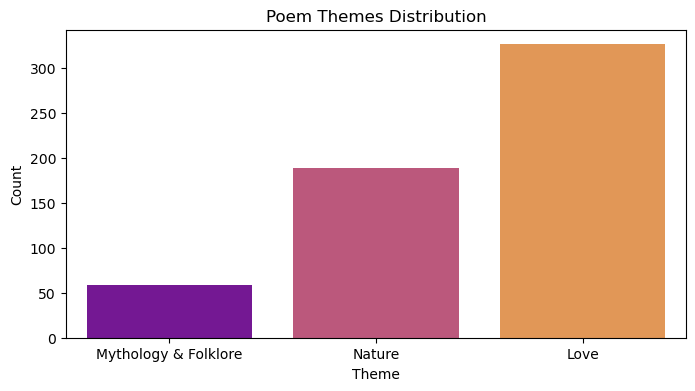

In [147]:
# (B) Distribution of Poem Themes
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='type', palette='plasma')
plt.title("Poem Themes Distribution")
plt.xlabel("Theme")
plt.ylabel("Count")
plt.show()

C:\Users\Rahul\AppData\Local\Temp\ipykernel_38264\3249445612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', palette='viridis')


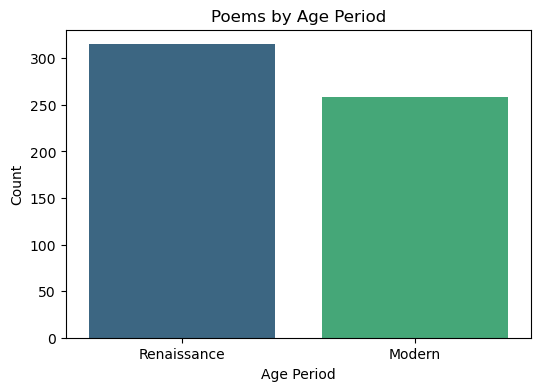

In [148]:
# (C) Distribution of Age Periods
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='age', palette='viridis')
plt.title("Poems by Age Period")
plt.xlabel("Age Period")
plt.ylabel("Count")
plt.show()

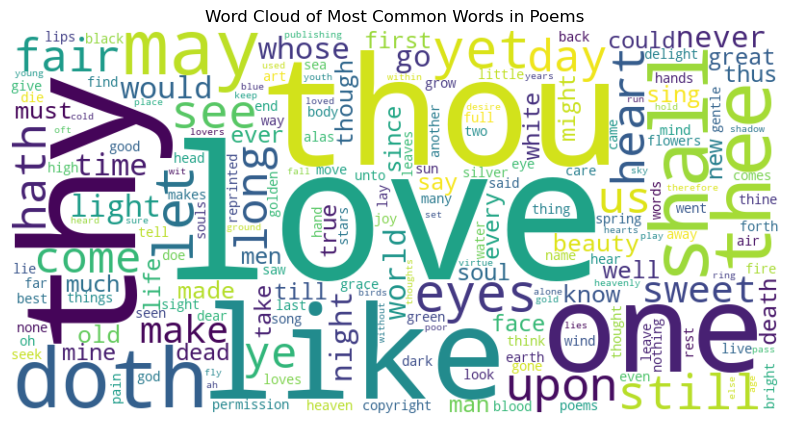

In [149]:
# (D) Word Cloud for Most Frequent Words in Poems
all_text = ' '.join(df['content'].dropna().astype(str))
stop_words = set(stopwords.words('english'))
word_tokens = word_tokenize(all_text.lower())
filtered_words = [word for word in word_tokens if word.isalpha() and word not in stop_words]

word_freq = Counter(filtered_words)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Most Common Words in Poems")
plt.show()

## 🛠 Text Preprocessing
### 1️⃣ Cleaning Text Data
- Remove punctuation, special characters, and numbers
- Convert text to lowercase
- Tokenization and lemmatization
- Remove stopwords

### 2️⃣ Handling Missing Data
- Drop or fill missing values
- Ensure dataset consistency

### 3️⃣ Text Normalization
- Standardize spelling variations
- Expand contractions (e.g., "I'm" → "I am")


In [150]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
%pip install contractions

import contractions

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [151]:
# Load dataset
file_path = r'C:\Users\Rahul\Desktop\Web_App\NLP\poems_dataset_cleaned.csv'
# Load the dataset with a different encoding
df = pd.read_csv(file_path, encoding='ISO-8859-1')

In [152]:
# Checking dataset structure
print(df.head())

                                    author  \
0                      WILLIAM SHAKESPEARE   
1  DUCHESS OF NEWCASTLE MARGARET CAVENDISH   
2                           THOMAS BASTARD   
3                           EDMUND SPENSER   
4                        RICHARD BARNFIELD   

                                             content  \
0  Let the bird of loudest lay\nOn the sole Arabi...   
1  Sir Charles into my chamber coming in,\nWhen I...   
2  Our vice runs beyond all that old men saw,\nAn...   
3  Lo I the man, whose Muse whilome did maske,\nA...   
4  Long have I longd to see my love againe,\nStil...   

                                 poem name          age                  type  \
0               The Phoenix and the Turtle  Renaissance  Mythology & Folklore   
1                 An Epilogue to the Above  Renaissance  Mythology & Folklore   
2                       Book 7, Epigram 42  Renaissance  Mythology & Folklore   
3  from The Faerie Queene: Book I, Canto I  Renaissance  Mytho

In [153]:
if 'content' not in df.columns:
    raise ValueError("Dataset must contain a content column")

# Initializing NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def expand_contractions(text):
    contractions_dict = {
        "i'm": "i am",
        "you're": "you are",
        "he's": "he is",
        "she's": "she is",
        "it's": "it is",
        "we're": "we are",
        "they're": "they are",
        "i've": "i have",
        "you've": "you have",
        "we've": "we have",
        "they've": "they have",
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "haven't": "have not",
        "hasn't": "has not",
        "hadn't": "had not",
        "won't": "will not",
        "wouldn't": "would not",
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "can't": "cannot",
        "couldn't": "could not",
        "shouldn't": "should not",
        "mightn't": "might not",
        "mustn't": "must not"
    }
    for contraction, full_form in contractions_dict.items():
        text = text.replace(contraction, full_form)
    return text

def preprocess_text(text):
    if pd.isna(text):
        return ""  # Handle missing values

    text = contractions.fix(text)  # Expand contractions
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation, special chars, numbers
    tokens = word_tokenize(text)  # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # Lemmatization & stopword removal
    return " ".join(tokens)

In [154]:
# Applying preprocessing
df['cleaned_poem'] = df['content'].apply(preprocess_text)

In [155]:
# Save cleaned dataset
cleaned_file_path = "poems_dataset_preprocessed.csv"
df.to_csv(cleaned_file_path, index=False)

## 🔍 Feature Engineering
### 1️⃣ Vectorization Techniques
- **TF-IDF** (Term Frequency-Inverse Document Frequency)
- **Word Embeddings** (Word2Vec, GloVe, BERT)

### 2️⃣ Additional Features
- **Poem Length** (word count, line count)
- **Sentiment Scores** using NLP libraries
- **Rhyme Pattern Analysis**


In [156]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from textblob import TextBlob
from collections import Counter
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import cmudict
from gensim.models import Word2Vec
from transformers import BertTokenizer, BertModel
import torch

nltk.download('punkt')
nltk.download('cmudict')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package cmudict to
[nltk_data]     C:\Users\Rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


True

In [157]:
# Loading dataset
df = pd.read_csv("poems_dataset_preprocessed.csv")  

In [158]:
def compute_tfidf(corpus):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(corpus)
    return tfidf_matrix

def compute_word2vec(sentences, vector_size=100):
    tokenized = [word_tokenize(sentence.lower()) for sentence in sentences]
    model = Word2Vec(sentences=tokenized, vector_size=vector_size, window=5, min_count=1, workers=4)
    return model

def compute_bert_embeddings(texts):
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    model = BertModel.from_pretrained("bert-base-uncased")
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1).squeeze().numpy())
    return np.array(embeddings)

def get_sentiment_scores(texts):
    return [TextBlob(text).sentiment.polarity for text in texts]

def count_rhymes(poems):
    pronouncing_dict = cmudict.dict()
    
    def last_syllable(word):
        word = word.lower()
        if word in pronouncing_dict:
            return pronouncing_dict[word][0][-1]  # Last syllable
        return ""
    
    rhyme_patterns = []
    for poem in poems:
        words = word_tokenize(poem.lower())
        rhymes = [last_syllable(word) for word in words if word.isalpha()]
        rhyme_count = Counter(rhymes)
        rhyme_patterns.append(len(rhyme_count))
    return rhyme_patterns

In [159]:
# Feature Engineering
df['poem_length'] = df['cleaned_poem'].apply(lambda x: len(x.split()))
df['char_count'] = df['cleaned_poem'].apply(len)
df['sentiment_score'] = get_sentiment_scores(df['cleaned_poem'])
df['rhyme_pattern_count'] = count_rhymes(df['cleaned_poem'])

In [160]:
# TF-IDF Features
tfidf_matrix = compute_tfidf(df['cleaned_poem'])

# Word2Vec Model
word2vec_model = compute_word2vec(df['cleaned_poem'])

# BERT Embeddings
bert_embeddings = compute_bert_embeddings(df['cleaned_poem'])

In [161]:
# Save to CSV
df.to_csv("poem_features.csv", index=False)

# Display Final Dataset
print(df.head())
print("Feature Engineering Completed and Saved to CSV")


                                    author  \
0                      WILLIAM SHAKESPEARE   
1  DUCHESS OF NEWCASTLE MARGARET CAVENDISH   
2                           THOMAS BASTARD   
3                           EDMUND SPENSER   
4                        RICHARD BARNFIELD   

                                             content  \
0  Let the bird of loudest lay\nOn the sole Arabi...   
1  Sir Charles into my chamber coming in,\nWhen I...   
2  Our vice runs beyond all that old men saw,\nAn...   
3  Lo I the man, whose Muse whilome did maske,\nA...   
4  Long have I longd to see my love againe,\nStil...   

                                 poem name          age                  type  \
0               The Phoenix and the Turtle  Renaissance  Mythology & Folklore   
1                 An Epilogue to the Above  Renaissance  Mythology & Folklore   
2                       Book 7, Epigram 42  Renaissance  Mythology & Folklore   
3  from The Faerie Queene: Book I, Canto I  Renaissance  Mytho

## 🤖 Model Selection & Training
- Implement ML models like **Naive Bayes, SVM, LSTMs, Transformers**
- Train models on **sentiment classification and theme recognition**


### (A) Eras(Age of Poem) Prediction Model

| **Era**                 | **Time Period**                  | **Notable Poets**                | **Characteristics** |
|------------------------|--------------------------------|--------------------------------|----------------------|
| **Ancient Poetry**      | Pre-5th Century CE             | Homer, Virgil                  | Epic poetry, oral tradition, mythology |
| **Medieval Poetry**     | 5th - 15th Century             | Dante, Chaucer                 | Religious themes, courtly love, alliteration |
| **Renaissance Poetry**  | 14th - 17th Century            | Shakespeare, John Donne        | Sonnets, metaphysical poetry, humanism |
| **Neoclassical Poetry** | 17th - 18th Century            | Alexander Pope, John Dryden    | Order, reason, heroic couplets |
| **Romantic Poetry**     | Late 18th - Early 19th Century | Wordsworth, Keats, Shelley     | Emotion, nature, individualism |
| **Victorian Poetry**    | 19th Century                   | Tennyson, Robert Browning      | Social themes, narrative poetry |
| **Modernist Poetry**    | Late 19th - Mid-20th Century   | T.S. Eliot, Ezra Pound         | Free verse, experimentation, stream of consciousness |
| **Postmodern Poetry**   | Mid-20th Century - Present     | Allen Ginsberg, Sylvia Plath   | Playful, fragmented, unconventional forms |
| **Contemporary Poetry** | 21st Century                   | Rupi Kaur, Amanda Gorman       | Personal, social justice themes, digital influence |

### **Model Selection**
Since we are predicting a **multiclass categorical label (Era of Poem)**, we are using:
- ✅ **Logistic Regression** (Baseline Model)
- ✅ **Random Forest**
- ✅ **XGBoost**
- ✅ **LSTM (Long Short-Term Memory Networks)**
- ✅ **Fine-tuned BERT for Classification**

### **Training and Evaluation**
- Training the model on labeled poetry text.
- Evaluating the models using **accuracy, precision, recall, and F1-score**.
 


In [162]:
import numpy as np
import pandas as pd
import re
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertModel
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.utils import to_categorical


In [163]:
import pandas as pd

df = pd.read_csv("processed_poems_with_ages.csv", encoding="ISO-8859-1")


In [164]:

# Clean Text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['cleaned_poem'] = df['content'].apply(clean_text)


In [165]:

# Encode Labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['age'])
labels = label_encoder.classes_

# Balance Classes
max_samples = df['label'].value_counts().max()
df_balanced = pd.concat([resample(df[df['label'] == label], replace=True, n_samples=max_samples, random_state=42) for label in df['label'].unique()])

max_samples = df['label'].value_counts().max()

# Resample each class separately
df_balanced = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=max_samples, replace=True, random_state=42)
)


C:\Users\Rahul\AppData\Local\Temp\ipykernel_38264\1893282234.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('label', group_keys=False).apply(


In [166]:
# Train-Test Split (Stratified)
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    df_balanced['cleaned_poem'], df_balanced['label'], 
    test_size=908, stratify=df_balanced['label'], random_state=42
)

#Print Dataset Shapes
print("Training Samples:", X_train1.shape[0])
print("Testing Samples:", X_test1.shape[0])
print("Label Distribution in Train:", y_train1.value_counts().to_dict())
print("Label Distribution in Test:", y_test1.value_counts().to_dict())

Training Samples: 16156
Testing Samples: 908
Label Distribution in Train: {7: 1796, 0: 1795, 6: 1795, 8: 1795, 4: 1795, 3: 1795, 1: 1795, 5: 1795, 2: 1795}
Label Distribution in Test: {8: 101, 1: 101, 2: 101, 4: 101, 3: 101, 6: 101, 0: 101, 5: 101, 7: 100}


In [167]:
# TF-IDF for traditional ML models
vectorizer1 = TfidfVectorizer(max_features=5000)
X_train_tfidf1 = vectorizer1.fit_transform(X_train1)
X_test_tfidf1 = vectorizer1.transform(X_test1)


# Print shape to debug
print("Feature shape:", X_test_tfidf1.shape)  


Feature shape: (908, 5000)


In [168]:
from sklearn.metrics import roc_auc_score
# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf1, y_train1)
log_reg_preds = log_reg.predict(X_test_tfidf1)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf1, y_train1)
rf_preds = rf.predict(X_test_tfidf1)

# Train XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_tfidf1, y_train1)
xgb_preds = xgb.predict(X_test_tfidf1)


c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:46:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [169]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# Binarize the labels for multi-class AUC
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test1)  # Convert labels to binary format

# Predict Probabilities
log_reg_probs = log_reg.predict_proba(X_test_tfidf1)
rf_probs = rf.predict_proba(X_test_tfidf1)
xgb_probs = xgb.predict_proba(X_test_tfidf1)

# Compute ROC AUC Scores (One-vs-Rest Approach)
auc_log_reg = roc_auc_score(y_test_binarized, log_reg_probs, multi_class='ovr')
auc_rf = roc_auc_score(y_test_binarized, rf_probs, multi_class='ovr')
auc_xgb = roc_auc_score(y_test_binarized, xgb_probs, multi_class='ovr')

print(f"Logistic Regression AUC: {auc_log_reg:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"XGBoost AUC: {auc_xgb:.4f}")


Logistic Regression AUC: 0.9972
Random Forest AUC: 0.9997
XGBoost AUC: 0.9996


In [170]:

from tensorflow.keras.layers import Dropout

# Tokenization for LSTM
max_words = 5000
max_len = 200
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train1)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train1), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test1), maxlen=max_len)

# LSTM Model
lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train1, epochs=5, batch_size=32, validation_data=(X_test_seq, y_test1))
lstm_preds = np.argmax(lstm_model.predict(X_test_seq), axis=1)


Epoch 1/5


c:\Users\Rahul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


505/505 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.5076 - loss: 1.3114 - val_accuracy: 0.8524 - val_loss: 0.3437
Epoch 2/5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8701 - loss: 0.2944 - val_accuracy: 0.8689 - val_loss: 0.2811
Epoch 3/5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9068 - loss: 0.2075 - val_accuracy: 0.9163 - val_loss: 0.1936
Epoch 4/5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9462 - loss: 0.1342 - val_accuracy: 0.9350 - val_loss: 0.1558
Epoch 5/5
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9629 - loss: 0.1075 - val_accuracy: 0.9581 - val_loss: 0.1320
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [171]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Evaluation
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"{model_name} -> Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
    print("=" * 80)

evaluate_model(y_test1, log_reg_preds, "Logistic Regression")
evaluate_model(y_test1, rf_preds, "Random Forest")
evaluate_model(y_test1, xgb_preds, "XGBoost")
evaluate_model(y_test1, lstm_preds, "LSTM")



Logistic Regression -> Accuracy: 0.9559, Precision: 0.9552, Recall: 0.9559, F1-score: 0.9553

Classification Report for Logistic Regression:

                     precision    recall  f1-score   support

     Ancient Poetry       0.92      0.97      0.95       101
Contemporary Poetry       1.00      1.00      1.00       101
    Medieval Poetry       0.99      1.00      1.00       101
   Modernist Poetry       0.96      0.97      0.97       101
Neoclassical Poetry       0.89      0.83      0.86       101
  Postmodern Poetry       1.00      1.00      1.00       101
 Renaissance Poetry       0.86      0.83      0.84       101
    Romantic Poetry       0.97      1.00      0.99       100
   Victorian Poetry       1.00      1.00      1.00       101

           accuracy                           0.96       908
          macro avg       0.96      0.96      0.96       908
       weighted avg       0.96      0.96      0.96       908

Random Forest -> Accuracy: 0.9868, Precision: 0.9868, Recall: 

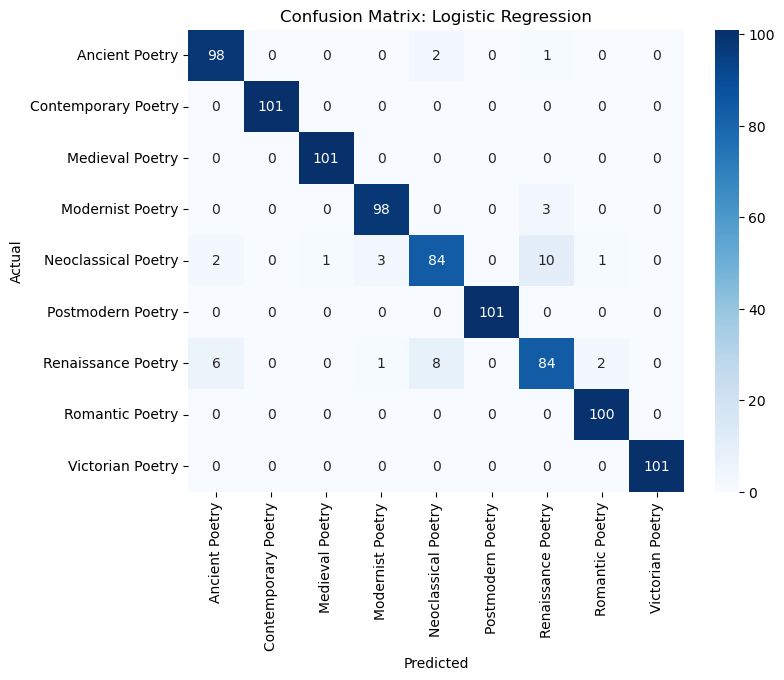

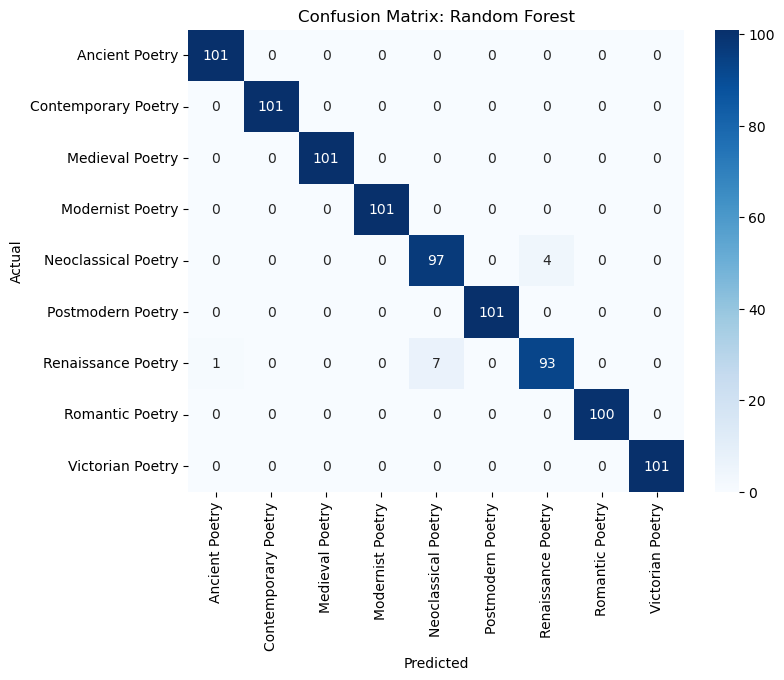

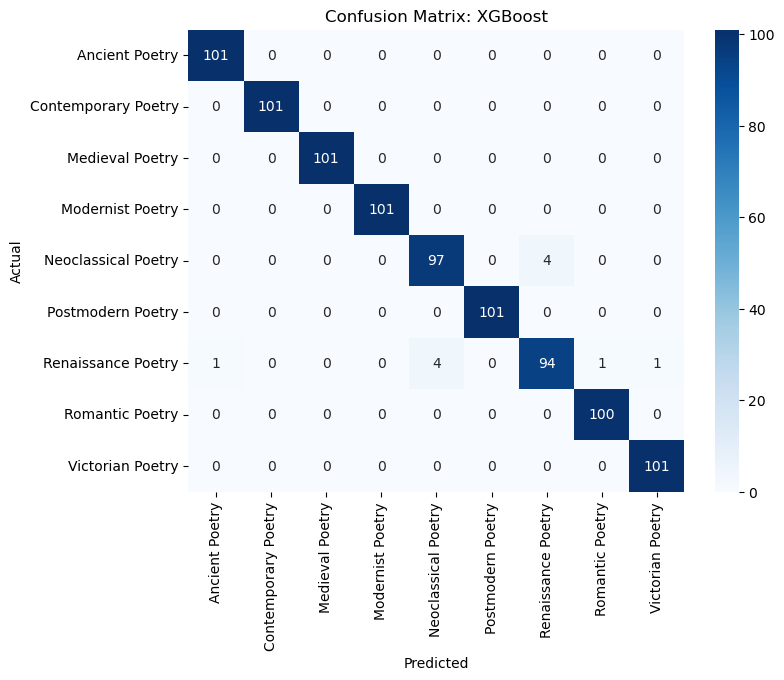

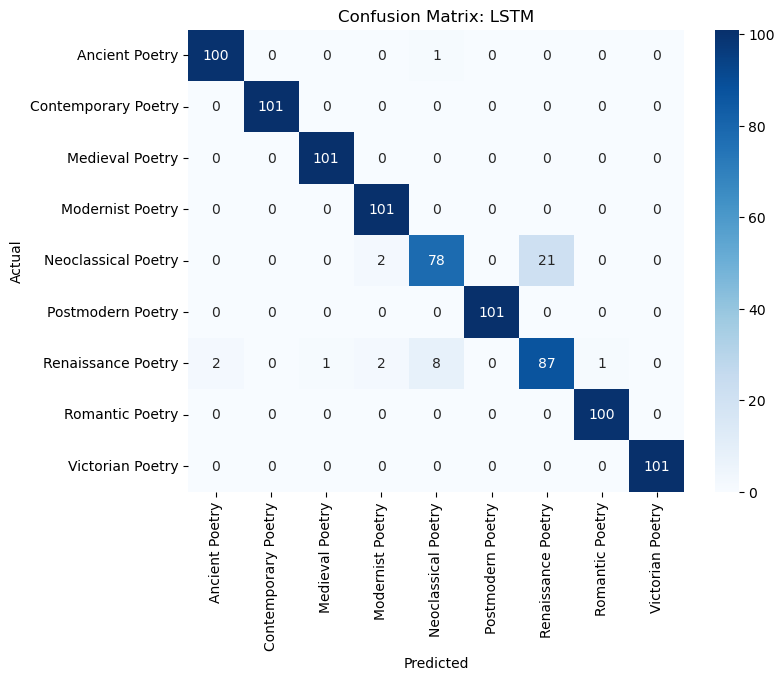

C:\Users\Rahul\AppData\Local\Temp\ipykernel_38264\3247724593.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


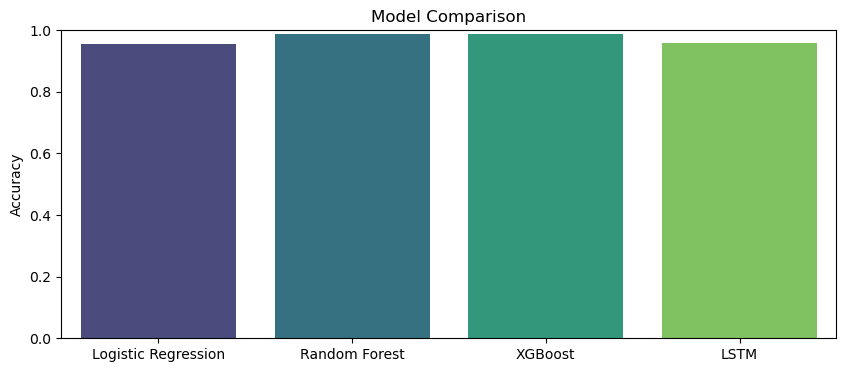

In [172]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Confusion Matrix & Bar Plot
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {title}')
    plt.show()

plot_confusion_matrix(y_test1, log_reg_preds, "Logistic Regression")
plot_confusion_matrix(y_test1, rf_preds, "Random Forest")
plot_confusion_matrix(y_test1, xgb_preds, "XGBoost")
plot_confusion_matrix(y_test1, lstm_preds, "LSTM")


# Bar Plot for Model Comparison
models = ["Logistic Regression", "Random Forest", "XGBoost", "LSTM"]
accuracies = [accuracy_score(y_test1, log_reg_preds), accuracy_score(y_test1, rf_preds), accuracy_score(y_test1, xgb_preds), accuracy_score(y_test1, lstm_preds)]

plt.figure(figsize=(10,4))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()


Logistic Regression AUC: 0.9925
Random Forest AUC: 0.9886


c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:48:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost AUC: 0.9938


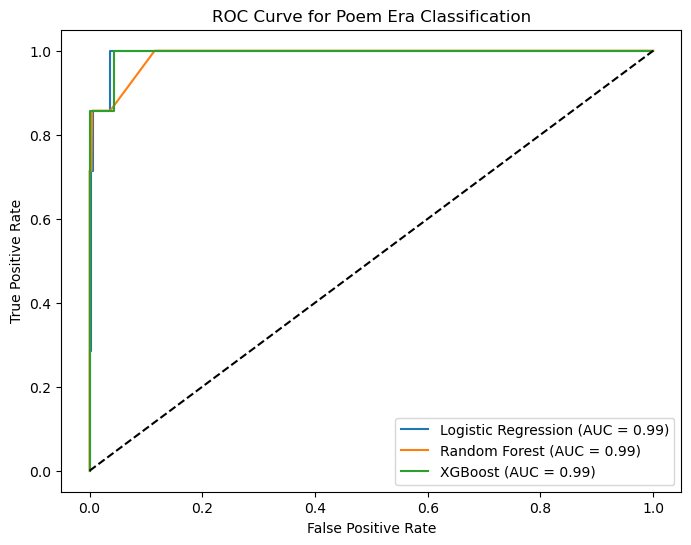

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import xgboost

# Encode 'age' labels
label_encoder = LabelEncoder()
df['age_encoded'] = label_encoder.fit_transform(df['age'])

# Prepare training data
X_train1, X_test1, y_train1, y_test1 = train_test_split(df['content'], df['age_encoded'], test_size=0.2, random_state=42)

# Convert text to numerical features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer1 = TfidfVectorizer(max_features=10000)
X_train_tfidf1 = vectorizer1.fit_transform(X_train1)
X_test_tfidf1 = vectorizer1.transform(X_test1)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": xgboost.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train and evaluate models
plt.figure(figsize=(8, 6))
for name, model in models.items():
    model.fit(X_train_tfidf1, y_train1)
    y_probs = model.predict_proba(X_test_tfidf1)
    y_preds = np.argmax(y_probs, axis=1)
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test1, y_probs[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"{name} AUC: {roc_auc:.4f}")
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot ROC Curve
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Poem Era Classification')
plt.legend()
plt.show()

In [174]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df["cleaned_poem"].astype(str).tolist()
# Save XGBoost model
with open("xgb1.pkl", "wb") as f:
    pickle.dump(xgb, f)
# Train TF-IDF with consistent features
vectorizer1 = TfidfVectorizer(max_features=5000)
vectorizer1.fit(texts)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer1.pkl", "wb") as f:
    pickle.dump(vectorizer1, f)
print("Vectorizer features:", len(vectorizer1.get_feature_names_out()))
# Save Label Encoder
with open("label_encoder1.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All necessary files saved successfully!")


Vectorizer features: 5000
All necessary files saved successfully!


# (B) 🐜 Poem Theme Prediction Model

## 🔍 Understanding Poetic Themes

Poems explore diverse **universal themes** that can be used as **classification labels**. Below is a structured list of common poetic themes:

| **Theme**                  | **Examples**                                  |
|----------------------------|----------------------------------------------|
| **Love & Relationships** ❤️  | Romantic Love, Unrequited Love, Forbidden Love, Family Love, Friendship |
| **Nature & Environment** 🌿 | Seasons (Spring, Summer, Autumn, Winter), Beauty of Nature, Animals & Wildlife, The Ocean & Water, The Sky, Stars, and Universe |
| **Life & Human Experience** 🌍 | Birth & Childhood, Coming of Age, Life Struggles, Success & Failure, Memories & Nostalgia |
| **Death & Mortality** ⚰️ | Mourning & Grief, Fear of Death, The Afterlife, The Cycle of Life |
| **Time & Transience** ⏳ | The Passage of Time, Aging, Change & Impermanence, The Fleeting Nature of Beauty |
| **Emotions & Feelings** 💔 | Joy & Happiness, Sorrow & Pain, Hope & Despair, Fear & Anxiety |
| **Spirituality & Religion** 🙏 | God & Faith, The Soul & Spiritual Journey, Heaven & Hell, Mythology & Legends |
| **Society & Culture** 🏛️ | War & Peace, Political Themes, Social Justice, Oppression & Freedom, Tradition vs. Modernity |
| **Identity & Self-Discovery** 🔍 | Finding Oneself, Gender & Sexuality, Mental Health & Well-being, Cultural Identity |
| **Dreams & Imagination** ✨ | Fantasy & Magic, The Power of Dreams, Surrealism & Abstract Thoughts, The Unknown & Mystical |
| **Conflict & Struggle** ⚔️ | Inner Conflict, War & Violence, Struggles for Power, Betrayal |
| **Mythology & Folklore** 🏺 | Greek, Roman, Norse, and Other Myths, Folk Stories & Fairy Tales, Legends of Heroes & Gods |
| **Adventure & Exploration** 🗺️ | Journeys & Travel, The Unknown & Discovery, Lost & Found |
| **Darkness & Horror** 👻 | Ghosts & Supernatural, Gothic & Macabre, Madness & Insanity |
| **Philosophy & Deep Thought** 🤔 | The Meaning of Life, Reality vs. Illusion, Existentialism |

---

### Model Selection
Since **theme classification is a multiclass problem**, we are going to be using:
- ✅ **Logistic Regression** (Baseline Model)
- ✅ **Random Forest** 
- ✅ **XGBoost** 
- ✅ **LSTM (Long Short-Term Memory Networks)** 

### Training & Evaluation
- Training the model on **labeled poetry data**.
- Evaluating the models using **accuracy, precision, recall, and F1-score**.




In [175]:
#Importing the Libraries 
import pandas as pd
import numpy as np
import re
import string
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight


In [176]:
# Load dataset
dataset = pd.read_csv("processed_poems_with_ages.csv")

In [177]:

# Function to clean text
def clean_text(text):
    text = str(text).lower()  # Ensure text is string before processing
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    return text
df['cleaned_text'] = df['content'].apply(clean_text)


In [178]:

# Convert text data to numerical features using TF-IDF
vectorizer2 = TfidfVectorizer(max_features=5000)  # You can adjust the number of features
X2 = vectorizer2.fit_transform(df['cleaned_text']).toarray()  # Convert to dense array

# Encode labels
label_encoder1 = LabelEncoder()
y2 = label_encoder1.fit_transform(df['type'])

# Handle Imbalanced Data using SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X2, y2)



In [179]:
# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)



In [180]:
# Training Different ML Models 
# Logistic Regression Model
log_reg1 = LogisticRegression(class_weight="balanced")
log_reg1.fit(X_train2, y_train2)
log_reg_preds1 = log_reg1.predict(X_test2)

# Random Forest Classifier
rf1 = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight="balanced")
rf1.fit(X_train2, y_train2)
rf_preds1 = rf1.predict(X_test2)

# XGBoost Classifier
xgb1 = XGBClassifier(n_estimators=150, max_depth=10)
xgb1.fit(X_train2, y_train2)
xgb_preds1 = xgb1.predict(X_test2)


In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# --- Extract relevant columns ---
texts = df['content'].astype(str).values  # Poems
labels = df['type'].astype(str).values    # Themes

# --- Encode labels ---
label_encoder = LabelEncoder()
y_lstm = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

# --- Tokenization ---
max_words = 10000  # Vocabulary size
max_len = 200      # Max sequence length
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
X_lstm = tokenizer.texts_to_sequences(texts)
X_lstm = pad_sequences(X_lstm, maxlen=max_len, padding='post', truncating='post')

# --- Train-test split (Test size = 170 samples) ---
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=170, random_state=42)

# --- Build LSTM model ---
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# --- Compile model ---
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- Train model ---
epochs = 10
batch_size = 32
model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_data=(X_test_lstm, y_test_lstm))

# --- Evaluate model ---
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm)
print(f"Test Accuracy: {accuracy:.2f}")

# --- Function for predicting themes ---
def predict_theme(poem):
    seq = tokenizer.texts_to_sequences([poem])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(padded_seq)
    return label_encoder.classes_[np.argmax(pred)]

# --- Example Prediction ---
poem_text = "The sun sets over the endless sea, whispering tales to the waves."
print("Predicted Theme:", predict_theme(poem_text))


Epoch 1/10


c:\Users\Rahul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


137/137 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.1800 - loss: 2.2780 - val_accuracy: 0.3000 - val_loss: 2.0283
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.2772 - loss: 1.9994 - val_accuracy: 0.3412 - val_loss: 1.8470
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.4049 - loss: 1.6805 - val_accuracy: 0.4529 - val_loss: 1.7091
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.5285 - loss: 1.3458 - val_accuracy: 0.4529 - val_loss: 1.6894
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.6400 - loss: 1.0555 - val_accuracy: 0.5529 - val_loss: 1.5453
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.7719 - loss: 0.7829 - val_accuracy: 0.5235 - val_loss: 1.7525
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.8560 - loss: 0.5344 - val_accuracy: 0.5529 - val_loss: 1.8736
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.8812 - loss: 0.4438 - val_accuracy: 0

In [182]:
""" import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


# Extract relevant columns
texts = df['content'].astype(str).values  # Poems
labels = df['type'].astype(str).values    # Themes

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)



# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_len = 256

class PoemDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
dataset_train = PoemDataset(X_train, y_train, tokenizer, max_len)
dataset_test = PoemDataset(X_test, y_test, tokenizer, max_len)

# DataLoaders
batch_size = 16
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size)

# Load BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer and Loss Function
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
criterion = nn.CrossEntropyLoss()

# Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in dataloader_train:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader_train):.4f}")

# Evaluation
model.eval()
total_correct, total_samples = 0, 0
with torch.no_grad():
    for batch in dataloader_test:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

accuracy = total_correct / total_samples
print(f"Test Accuracy: {accuracy:.2f}")

# Prediction Function
def predict_theme(poem):
    model.eval()
    encoding = tokenizer(poem, truncation=True, padding='max_length', max_length=max_len, return_tensors='pt')
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        output = model(input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(output.logits, dim=1).item()
    return label_encoder.classes_[prediction]

# Example Prediction
poem_text = "The sun sets over the endless sea, whispering tales to the waves."
print("Predicted Theme:", predict_theme(poem_text))
 """

' import pandas as pd\nimport numpy as np\nimport torch\nimport torch.nn as nn\nfrom torch.utils.data import Dataset, DataLoader\nfrom transformers import BertTokenizer, BertForSequenceClassification, AdamW\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import LabelEncoder\nfrom imblearn.over_sampling import SMOTE\n\n\n# Extract relevant columns\ntexts = df[\'content\'].astype(str).values  # Poems\nlabels = df[\'type\'].astype(str).values    # Themes\n\n# Encode labels\nlabel_encoder = LabelEncoder()\ny = label_encoder.fit_transform(labels)\nnum_classes = len(label_encoder.classes_)\n\n\n\n# Split dataset\nX_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)\n\n# Tokenization\ntokenizer = BertTokenizer.from_pretrained(\'bert-base-uncased\')\nmax_len = 256\n\nclass PoemDataset(Dataset):\n    def __init__(self, texts, labels, tokenizer, max_len):\n        self.texts = texts\n        self.labels = 

In [183]:
# Evaluation
def evaluate_model(name, y_true, y_pred):
    print(f"{name} Accuracy: {accuracy_score(y_true, y_pred):.2f}")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

evaluate_model("Logistic Regression", y_test2, log_reg_preds1)
evaluate_model("Random Forest", y_test2, rf_preds1)
evaluate_model("XGBoost", y_test2, xgb_preds1)



# Compare Model Performance
model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LSTM"]
model_accuracies = [
    accuracy_score(y_test2, log_reg_preds1),
    accuracy_score(y_test2, rf_preds1),
    accuracy_score(y_test2, xgb_preds1),
    
]

Logistic Regression Accuracy: 0.82
                             precision    recall  f1-score   support

       Dreams & Imagination       0.84      0.89      0.86       182
Emotions & Human Experience       0.81      0.81      0.81       196
     Family & Relationships       0.70      0.76      0.73       180
               Life & Death       0.62      0.58      0.60       197
                       Love       0.98      1.00      0.99       160
             Love & Romance       0.83      0.85      0.84       180
       Mythology & Folklore       0.97      0.97      0.97       189
                     Nature       0.93      0.96      0.94       186
           Nature & Seasons       0.68      0.73      0.71       197
        Society & Struggles       0.85      0.79      0.82       189
                War & Peace       0.89      0.77      0.83       197

                   accuracy                           0.82      2053
                  macro avg       0.83      0.83      0.83      20

C:\Users\Rahul\AppData\Local\Temp\ipykernel_38264\3957214785.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=accuracy_df, palette="viridis")


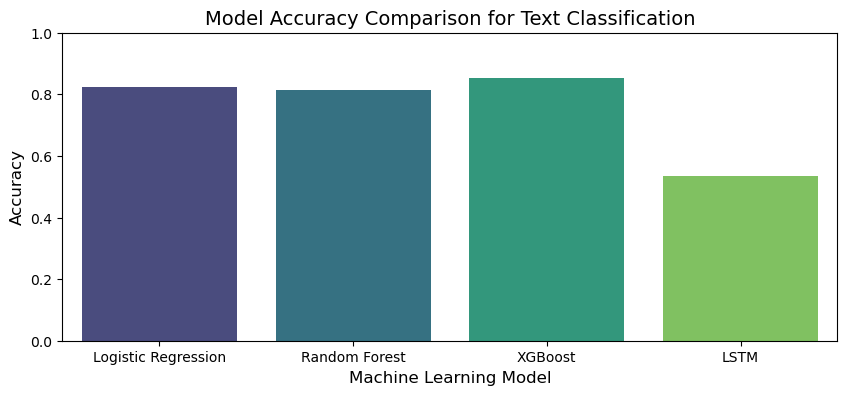

In [184]:
model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LSTM"]
model_accuracies = [
    accuracy_score(y_test2, log_reg_preds1),
    accuracy_score(y_test2, rf_preds1),
    accuracy_score(y_test2, xgb_preds1),
    accuracy  # LSTM test accuracy from model.evaluate()
]

# Create DataFrame
accuracy_df = pd.DataFrame({"Model": model_names, "Accuracy": model_accuracies})

# Plot Accuracy Comparison
plt.figure(figsize=(10, 4))
sns.barplot(x="Model", y="Accuracy", data=accuracy_df, palette="viridis")
plt.ylim(0.0, 1.0)
plt.title("Model Accuracy Comparison for Text Classification", fontsize=14)
plt.xlabel("Machine Learning Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.show()

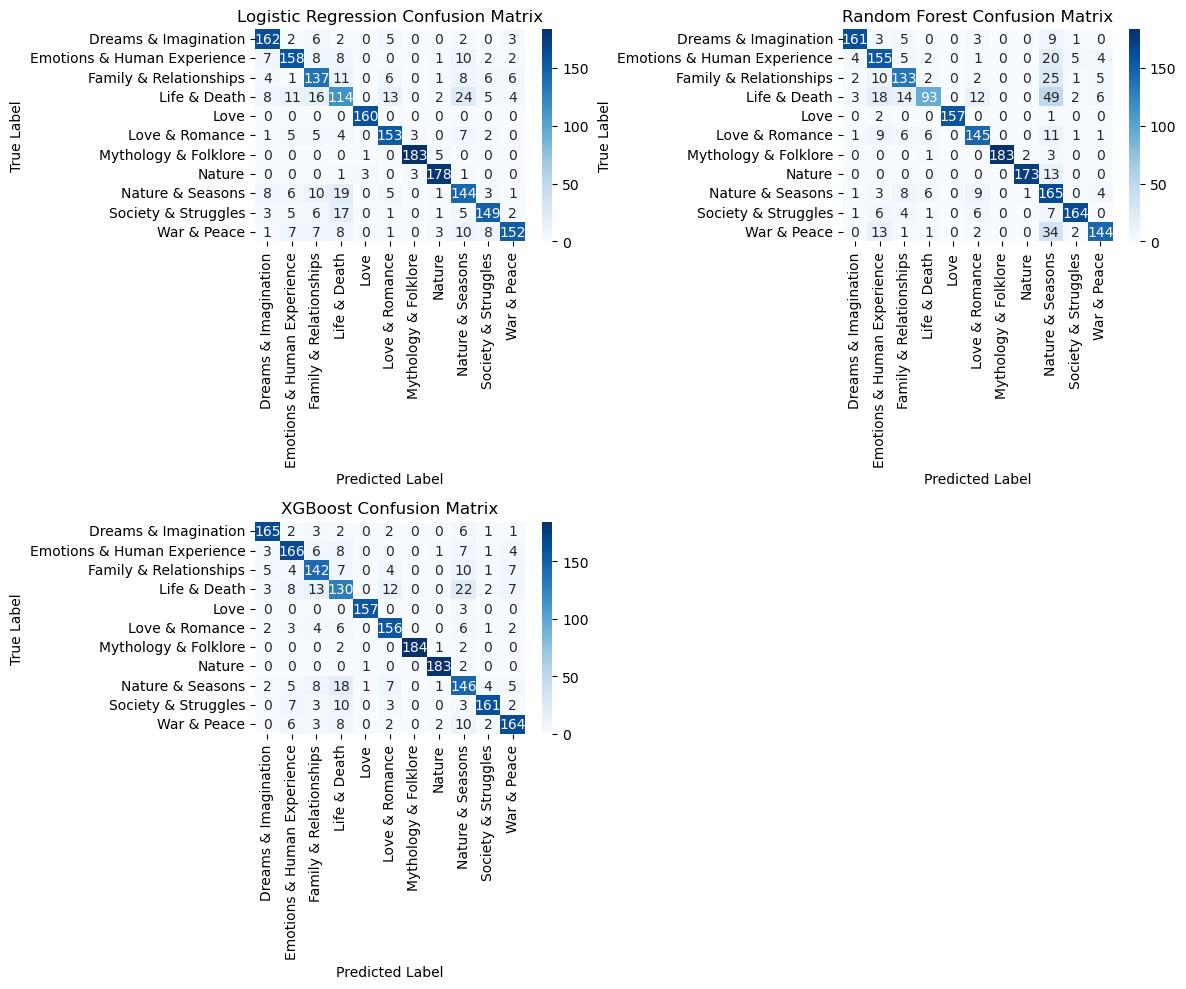

In [185]:
model_preds = {
    "Logistic Regression": log_reg_preds1,
    "Random Forest": rf_preds1,
    "XGBoost": xgb_preds1,
    
}

plt.figure(figsize=(12, 10))

for i, (model_name, preds) in enumerate(model_preds.items(), 1):
    cm = confusion_matrix(y_test2, preds)
    
    plt.subplot(2, 2, i) 
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()


In [186]:
import pickle

# Save TF-IDF Vectorizer
with open("theme_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer2, f)

# Save XGBoost Model
with open("theme_xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb1, f)

# Save Label Encoder
with open("theme_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder1, f)

print("✅ All necessary files saved!")


✅ All necessary files saved!


# (C) 😊 **Poem Sentiment Analysis Model**  

## 🔍 **Understanding Sentiment in Poetry**  
Poems express a wide range of **emotions and sentiments**, which can be categorized into **three primary sentiment classes**:  

| **Sentiment**         | **Description** | **Examples** |
|-----------------------|----------------|-------------|
| **Positive** 😊  | Expresses joy, love, hope, admiration, beauty, peace, or triumph. | Love poems, uplifting nature poetry, inspirational verses, poems of celebration. |
| **Negative** 😢  | Reflects sadness, despair, grief, anger, loss, pain, or horror. | Elegies, war poems, heartbreak poetry, Gothic horror poetry. |
| **Neutral** 😐  | Descriptive, observational, or philosophical poetry without strong emotional bias. | Haikus, narrative poetry, abstract poetry, philosophical reflections. |

---

## 🔬 **Sentiment Classification Models**  
Since **sentiment analysis is a classification task**, we will use:  
- ✅ **Logistic Regression** (Baseline Model)  
- ✅ **Random Forest**  
- ✅ **XGBoost**  
- ✅ **LSTM (Long Short-Term Memory Networks)**  
- ✅ **Fine-Tuned BERT**  

---

## 📊 **Training & Evaluation Metrics**  
- **Accuracy:** Measures overall correctness.  
- **Precision & Recall:** Helps evaluate the quality of sentiment predictions.  
- **F1-Score:** Balances precision and recall.  
- **ROC-AUC Score:** Evaluates model performance on sentiment classification.  




In [187]:
# Importing the libraries
import tensorflow as tf
import numpy as np
import pandas as pd
from transformers import DistilBertTokenizer
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [188]:
# Load dataset
dataset = load_dataset("poem_sentiment")


In [189]:
# Convert dataset to DataFrame
def dataset_to_dataframe(dataset):
    df = pd.DataFrame(dataset["train"])
    return df

df = dataset_to_dataframe(dataset)

# Preprocessing
X = df["verse_text"]
y = df["label"]

In [190]:
# Split data
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.2, random_state=42)


In [191]:
# TF-IDF Vectorization for ML models
tfidf3 = TfidfVectorizer(max_features=5000)
X_train_tfidf3 = tfidf3.fit_transform(X_train3)
X_test_tfidf3 = tfidf3.transform(X_test3)


In [192]:
# Training Different ML Models 
# Logistic Regression
log_reg2 = LogisticRegression()
log_reg2.fit(X_train_tfidf3, y_train3)
y_pred_log_reg = log_reg2.predict(X_test_tfidf3)
log_reg_acc = accuracy_score(y_test3, y_pred_log_reg)
print("Logistic Regression Accuracy:", log_reg_acc)

# Random Forest
rf2 = RandomForestClassifier()
rf2.fit(X_train_tfidf3, y_train3)
y_pred_rf = rf2.predict(X_test_tfidf3)
rf_acc = accuracy_score(y_test3, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

# XGBoost
xgb2 = XGBClassifier()
xgb2.fit(X_train_tfidf3, y_train3)
y_pred_xgb = xgb2.predict(X_test_tfidf3)
xgb_acc = accuracy_score(y_test3, y_pred_xgb)
print("XGBoost Accuracy:", xgb_acc)

Logistic Regression Accuracy: 0.6312849162011173
Random Forest Accuracy: 0.6256983240223464
XGBoost Accuracy: 0.6089385474860335


In [193]:
# Tokenization for LSTM
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train3)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train3), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test3), maxlen=100)

# LSTM Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_seq, y_train3, validation_data=(X_test_seq, y_test3), epochs=5, batch_size=32)

# LSTM Predictions
y_pred_lstm = np.argmax(model.predict(X_test_seq), axis=1)
lstm_acc = accuracy_score(y_test3, y_pred_lstm)
print("LSTM Accuracy:", lstm_acc)


Epoch 1/5


c:\Users\Rahul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5428 - loss: 1.2162 - val_accuracy: 0.6201 - val_loss: 1.0527
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6219 - loss: 1.0253 - val_accuracy: 0.6201 - val_loss: 1.0452
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6180 - loss: 1.0080 - val_accuracy: 0.6201 - val_loss: 1.0870
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6107 - loss: 0.9682 - val_accuracy: 0.6089 - val_loss: 0.9994
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7183 - loss: 0.7396 - val_accuracy: 0.6257 - val_loss: 1.1920
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
LSTM Accuracy: 0.6256983240223464


In [194]:
import transformers
print(transformers.__version__)
import tensorflow as tf
print(tf.__version__)


4.46.2
2.18.0


In [195]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding
from datasets import load_dataset
import numpy as np

# 📥 Load Poem Sentiment Dataset
dataset = load_dataset("poem_sentiment")

# ✅ Define Model and Tokenizer
model_name = "bert-base-uncased"
num_labels = 4  # 'poem_sentiment' has 4 classes: negative, neutral, positive, mixed

sentiment_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 🔄 Tokenization Function
def tokenize_data(batch):
    return tokenizer(batch["verse_text"], truncation=True, padding=True, max_length=512)

# Apply Tokenization
tokenized_datasets = dataset.map(tokenize_data, batched=True)

# ✅ Convert Datasets to TensorFlow format
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="tf")

train_dataset = tokenized_datasets["train"].to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    batch_size=8,  # Reduce batch size to avoid memory issues
    shuffle=True,
    collate_fn=data_collator
)

val_dataset = tokenized_datasets["validation"].to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    batch_size=8,
    shuffle=False,
    collate_fn=data_collator
)

# ✅ Define Optimizer & Loss Function
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# 🚀 Custom Training Loop
epochs = 3

for epoch in range(epochs):
    print(f"\n🚀 Epoch {epoch+1}/{epochs}")

    # Training Step
    for step, (batch, labels) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            outputs = sentiment_model(**batch, training=True)
            loss = loss_fn(labels, outputs.logits)
        
        gradients = tape.gradient(loss, sentiment_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, sentiment_model.trainable_variables))

        if step % 10 == 0:
            print(f"Step {step}: Loss = {loss.numpy():.4f}")

    # Validation Step
    val_loss = []
    for batch, labels in val_dataset:
        outputs = sentiment_model(**batch, training=False)
        loss = loss_fn(labels, outputs.logits)
        val_loss.append(loss.numpy())

    print(f"Validation Loss: {np.mean(val_loss):.4f}")

# 💾 Save Fine-Tuned Model
sentiment_model.save_pretrained("poem_sentiment_bert_model")
tokenizer.save_pretrained("poem_sentiment_bert_model")

print("🎉 Model training complete and saved!")

# 📌 Label Mapping
label_map = {0: "Negative", 1: "Neutral", 2: "Positive", 3: "Mixed"}

# 📝 Sentiment Prediction Function
def predict_sentiment(poem_text):
    """Predict the sentiment of a given poem."""
    inputs = tokenizer(poem_text, return_tensors="tf", truncation=True, padding=True, max_length=512)
    logits = sentiment_model(**inputs).logits
    predicted_label = np.argmax(logits.numpy(), axis=1)[0]
    return label_map[predicted_label]



All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\Rahul\anaconda3\Lib\site-packages\datasets\arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings


🚀 Epoch 1/3
Step 0: Loss = 1.4912
Step 10: Loss = 0.9489
Step 20: Loss = 1.2482
Step 30: Loss = 1.1050
Step 40: Loss = 0.9519
Step 50: Loss = 0.9549
Step 60: Loss = 0.9513
Step 70: Loss = 1.0647
Step 80: Loss = 1.5160
Step 90: Loss = 0.8749
Step 100: Loss = 0.8178
Step 110: Loss = 0.8069
Validation Loss: 0.5839

🚀 Epoch 2/3
Step 0: Loss = 0.5607
Step 10: Loss = 0.4556
Step 20: Loss = 0.4364
Step 30: Loss = 1.2679
Step 40: Loss = 0.1703
Step 50: Loss = 0.2414
Step 60: Loss = 0.9719
Step 70: Loss = 0.9136
Step 80: Loss = 0.1506
Step 90: Loss = 0.2424
Step 100: Loss = 0.6800
Step 110: Loss = 0.5144
Validation Loss: 0.6018

🚀 Epoch 3/3
Step 0: Loss = 0.3399
Step 10: Loss = 1.0274
Step 20: Loss = 0.0688
Step 30: Loss = 0.5719
Step 40: Loss = 0.2380
Step 50: Loss = 0.6404
Step 60: Loss = 0.6932
Step 70: Loss = 0.0959
Step 80: Loss = 0.1265
Step 90: Loss = 0.0974
Step 100: Loss = 1.0299
Step 110: Loss = 0.1605
Validation Loss: 0.7342
🎉 Model training complete and saved!


Some layers from the model checkpoint at poem_sentiment_bert_model were not used when initializing TFBertForSequenceClassification: ['dropout_189']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at poem_sentiment_bert_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.



📜 Classification Report:

              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81        19
     Neutral       0.65      0.69      0.67        16
    Positive       0.91      0.86      0.88        69
       Mixed       0.00      0.00      0.00         0

    accuracy                           0.82       104
   macro avg       0.60      0.58      0.59       104
weighted avg       0.85      0.82      0.83       104



c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


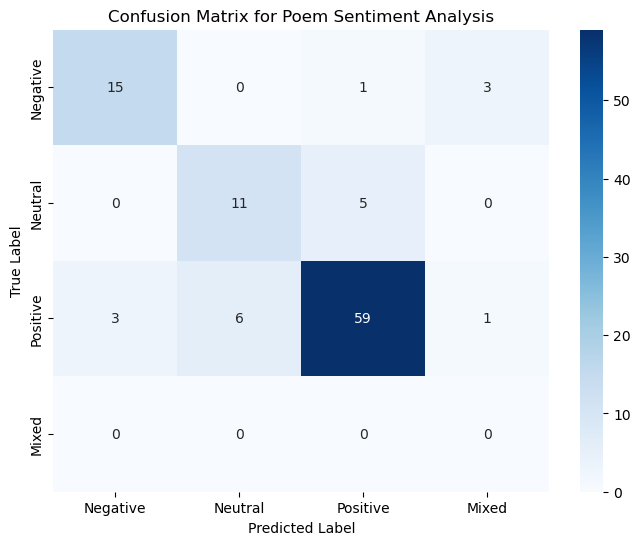

In [196]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 📥 Load Poem Sentiment Dataset
dataset = load_dataset("poem_sentiment")

# ✅ Load Fine-Tuned Model & Tokenizer
sentiment_model = TFAutoModelForSequenceClassification.from_pretrained("poem_sentiment_bert_model")
tokenizer = AutoTokenizer.from_pretrained("poem_sentiment_bert_model")

# 📌 Correct Label Mapping (for 4 sentiment classes)
label_map = {0: "Negative", 1: "Neutral", 2: "Positive", 3: "Mixed"}  
reverse_label_map = {v: k for k, v in label_map.items()}  

def predict_sentiment(poem_text):
    """Predict the sentiment of a given poem and return numeric class."""
    inputs = tokenizer(poem_text, return_tensors="tf", truncation=True, padding=True, max_length=512)
    logits = sentiment_model(**inputs).logits
    predicted_label = np.argmax(logits.numpy(), axis=1)[0]
    return predicted_label  # Returns number (0, 1, 2, or 3)

# 📊 Evaluate Model on Test Set
true_labels = []
pred_labels = []

for poem, label in zip(dataset["test"]["verse_text"], dataset["test"]["label"]):
    pred = predict_sentiment(poem)  # Returns numeric label
    true_labels.append(label)  # Numeric
    pred_labels.append(pred)   # Numeric

# ✅ Generate Classification Report
print("\n📜 Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=label_map.values()))

# 🔄 Confusion Matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# 🔄 Confusion Matrix with 4 Labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_map.values(), yticklabels=label_map.values())  
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Poem Sentiment Analysis")
plt.show()


Some layers from the model checkpoint at poem_sentiment_bert_model were not used when initializing TFBertForSequenceClassification: ['dropout_189']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at poem_sentiment_bert_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.
c:\Users\Rahul\anaconda3\Lib\site-packages\matplotlib\anim

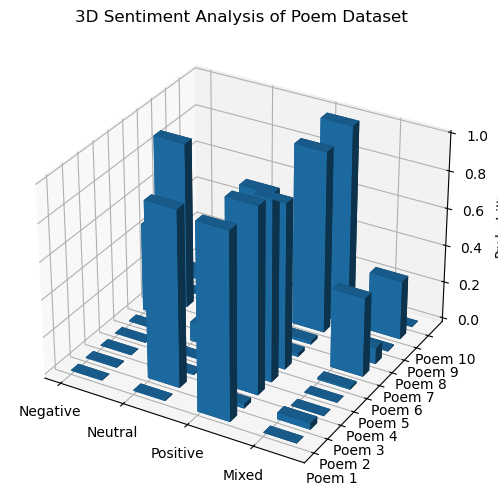

In [197]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

# 📥 Load Poem Sentiment Dataset
dataset = load_dataset("poem_sentiment")

# ✅ Define Model and Tokenizer
model_name = "bert-base-uncased"
num_labels = 4  # 'poem_sentiment' has 4 classes: negative, neutral, positive, mixed

sentiment_model = TFAutoModelForSequenceClassification.from_pretrained("poem_sentiment_bert_model")
tokenizer = AutoTokenizer.from_pretrained("poem_sentiment_bert_model")

# 📌 Label Mapping
label_map = {0: "Negative", 1: "Neutral", 2: "Positive", 3: "Mixed"}

# 📝 Sentiment Prediction Function
def predict_sentiment(poem_text):
    """Predict the sentiment probabilities of a given poem."""
    inputs = tokenizer(poem_text, return_tensors="tf", truncation=True, padding=True, max_length=512)
    logits = sentiment_model(**inputs).logits
    probs = tf.nn.softmax(logits, axis=1).numpy()  # Convert to probabilities
    return probs

# 🎯 Get Sentiment Probabilities for Sample Poems
sample_poems = dataset["test"]["verse_text"][:10]  # Take 10 poems
probabilities = np.array([predict_sentiment(poem)[0] for poem in sample_poems])

# 📊 3D Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

# Define axis data
x_labels = ["Negative", "Neutral", "Positive", "Mixed"]
x_pos = np.arange(len(x_labels))
y_pos = np.arange(len(sample_poems))
X, Y = np.meshgrid(x_pos, y_pos)

# Flatten arrays for 3D plotting
Z = probabilities.flatten()
X_flat = X.flatten()
Y_flat = Y.flatten()

bars = ax.bar3d(X_flat, Y_flat, np.zeros_like(Z), 0.5, 0.5, Z, shade=True)

# 🎥 Animation Function
def update(frame):
    for i, b in enumerate(bars):
        b.set_3d_properties(Z + np.sin(frame / 10) * 0.02)  # Small movement effect

ani = animation.FuncAnimation(fig, update, frames=100, interval=50)

# 📌 Labels and Titles
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"Poem {i+1}" for i in range(len(sample_poems))])
ax.set_zlabel("Probability")
ax.set_title("3D Sentiment Analysis of Poem Dataset")

# 📢 Show Animated 3D Plot
plt.show()


C:\Users\Rahul\AppData\Local\Temp\ipykernel_38264\3173159576.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


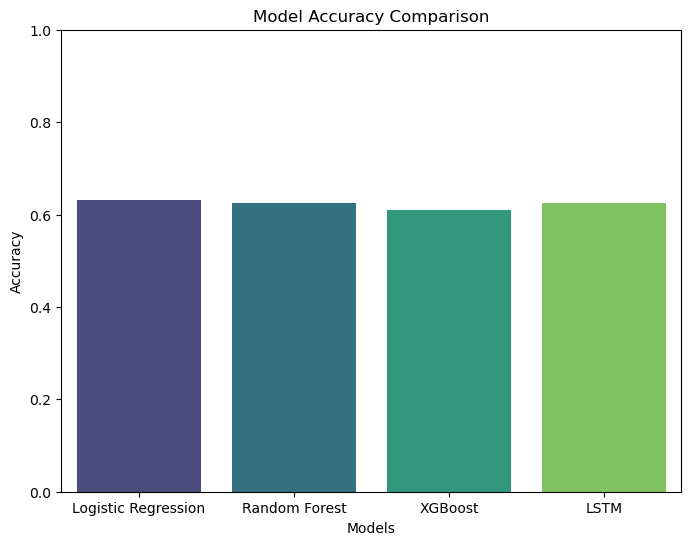

In [198]:

import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import confusion_matrix
# Accuracy Bar Plot
model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LSTM"]
accuracies = [log_reg_acc, rf_acc, xgb_acc, lstm_acc]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

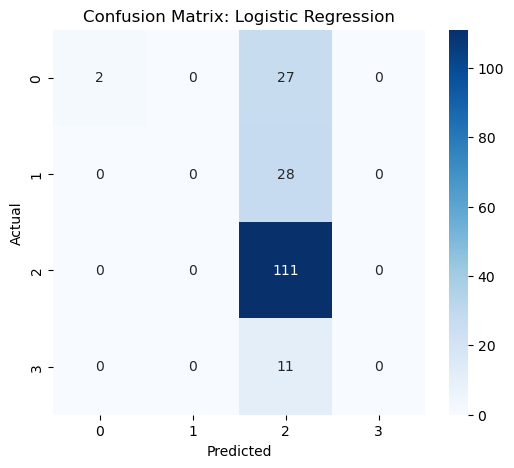

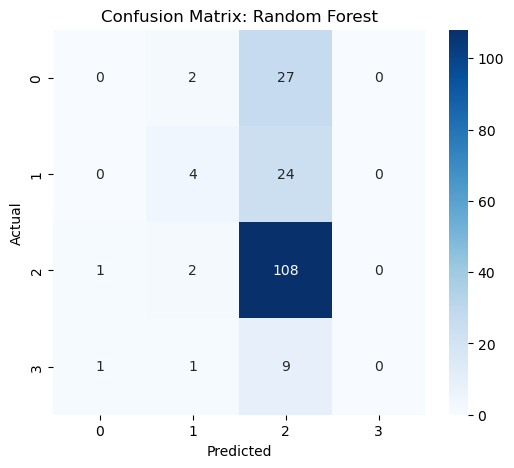

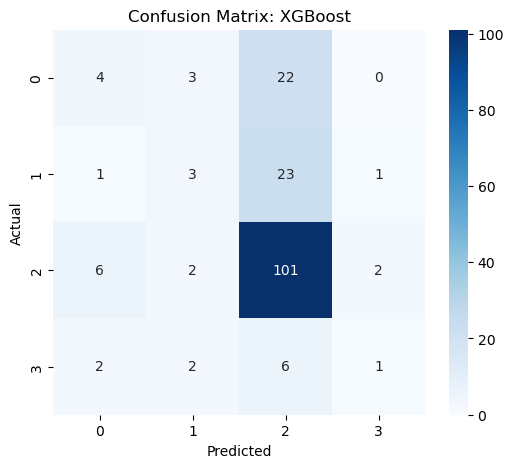

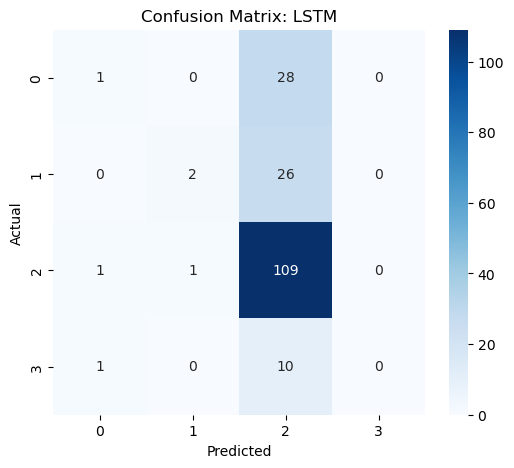

In [199]:
# Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test3), yticklabels=set(y_test3))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {title}")
    plt.show()

plot_confusion_matrix(y_test3, y_pred_log_reg, "Logistic Regression")
plot_confusion_matrix(y_test3, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test3, y_pred_xgb, "XGBoost")
plot_confusion_matrix(y_test3, y_pred_lstm, "LSTM")


🔹 Evaluating: Sentiment Analysis

Logistic Regression Average AUC for Sentiment: 0.7073
Random Forest Average AUC for Sentiment: 0.6216
XGBoost Average AUC for Sentiment: 0.6879


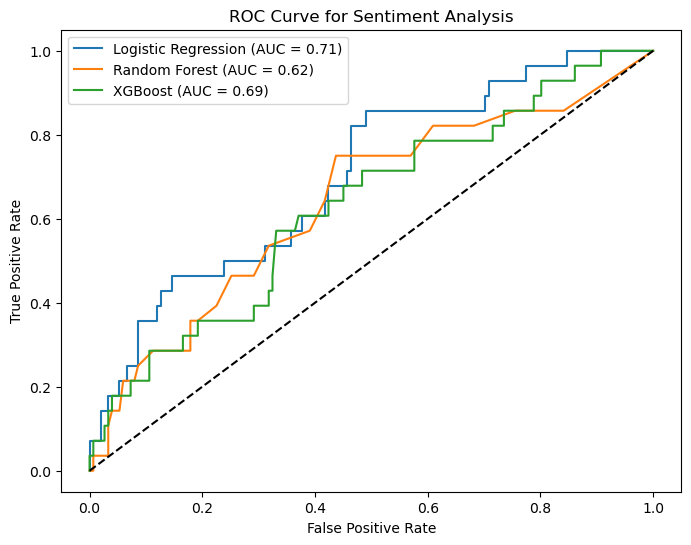

In [200]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

# Sentiment Analysis
print("\n🔹 Evaluating: Sentiment Analysis\n")

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss')
}
plt.figure(figsize=(8, 6))
for name, model in models.items():
    model.fit(X_train_tfidf3, y_train3)
    y_probs = model.predict_proba(X_test_tfidf3)
    
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(y_probs.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_test3 == i, y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    avg_auc = np.mean(list(roc_auc.values()))
    print(f"{name} Average AUC for Sentiment: {avg_auc:.4f}")
    plt.plot(fpr[1], tpr[1], label=f'{name} (AUC = {avg_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Sentiment Analysis')
plt.legend()
plt.show()

In [201]:
import pickle

# Save the trained TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf3, f)

# Save the fine-tuned BERT model
sentiment_model.save_pretrained("poem_sentiment_bert_model")

# Save the tokenizer
tokenizer.save_pretrained("poem_sentiment_bert_model")


('poem_sentiment_bert_model\\tokenizer_config.json',
 'poem_sentiment_bert_model\\special_tokens_map.json',
 'poem_sentiment_bert_model\\vocab.txt',
 'poem_sentiment_bert_model\\added_tokens.json',
 'poem_sentiment_bert_model\\tokenizer.json')

# 🎭 **Poetic Structure Analysis: Rhyme Scheme & Poetic Form Detection**  

## 🔍 **Understanding Rhyme Schemes in Poetry**  
A **rhyme scheme** is the pattern of end rhymes in a poem, usually represented by **letters (A, B, C, etc.)**. Detecting rhyme schemes helps in **categorizing poetic forms** and understanding a poem's structure.  

---

## 📜 **Common Rhyme Schemes in Poetry**  

### 🔹 **1. Simple Rhyme Schemes**  
| **Rhyme Scheme** | **Pattern** | **Example** |
|------------------|------------|-------------|
| **AABB (Couplet Rhyme)** | Consecutive rhyming lines | "The sky is blue (A) / The grass has dew (A) / The birds all sing (B) / As bells do ring (B)" |
| **ABAB (Alternate Rhyme)** | Alternating rhymes every other line | "In silent night (A) / The moonlight glows (B) / The river flows (A) / With silver light (B)" |
| **ABBA (Enclosed Rhyme / Chiasmus)** | First and last line rhyme, middle lines rhyme | "The waves crash bright (A) / Against the shore (B) / The sea will roar (B) / Beneath the night (A)" |
| **AAAA (Monorhyme)** | Every line rhymes | "The sky is vast (A) / It stretches fast (A) / The clouds move past (A) / Until they last (A)" |
| **AABA (Rubaiyat Rhyme)** | 3 rhyming lines, with 1 non-rhyming line | "The wind will call (A) / The moon is high (A) / I hear its sigh (B) / And watch it fall (A)" |
| **ABCB (Ballad Rhyme)** | 2nd and 4th lines rhyme, 1st and 3rd don't | "The stars above (A) / They shine so bright (B) / The world is vast (C) / They guide at night (B)" |

---

### 🔹 **2. Complex & Advanced Rhyme Schemes**  
| **Rhyme Scheme** | **Pattern** | **Example** |
|------------------|------------|-------------|
| **ABABCC (Sestet Rhyme)** | Alternate rhyme + rhyming couplet | "A gentle breeze (A) / The leaves do fall (B) / Beneath the trees (A) / A bird will call (B) / The world is bright (C) / With morning light (C)" |
| **AABBA (Limerick Rhyme)** | 1st, 2nd, and 5th rhyme, 3rd and 4th are different | "A fellow once knew (A) / A pirate so true (A) / He sailed the sea (B) / With joyful glee (B) / And drank all his crew (A)" |
| **AABBCC (Couplet Sextet)** | 3 sets of rhyming couplets | "The river flows (A) / The cold wind blows (A) / The sky so wide (B) / No place to hide (B) / The sun is bright (C) / It gives its light (C)" |
| **ABCDDCBA (Palindromic Rhyme)** | A mirrored rhyme structure | "Upon the sea (A) / The storm is near (B) / The waves arise (C) / The wind is wild (D) / The wind is wild (D) / The waves arise (C) / The storm is near (B) / Upon the sea (A)" |
| **ABCDE (Free Verse Rhyme)** | No repeated rhymes | "The wind whispers (A) / The stars glow (B) / The night deepens (C) / The moon fades (D) / The world sleeps (E)" |

---

## 📜 **Poetic Form Detection Based on Rhyme Schemes**  

### 🔹 **3. Sonnet Rhyme Schemes**  
| **Sonnet Type** | **Rhyme Scheme** | **Example** |
|----------------|----------------|-------------|
| **Shakespearean Sonnet** | ABABCDCDEFEFGG | 14-line structure with couplet at the end |
| **Petrarchan Sonnet** | ABBAABBACDCDCD | First 8 lines (ABBAABBA) are fixed, last 6 (CDCDCD) can vary |
| **Spenserian Sonnet** | ABABBCBCCDCDEE | Similar to Shakespearean but with interlocking rhymes |

---

### 🔹 **4. Fixed Forms with Unique Rhyme Schemes**  
| **Poetic Form** | **Rhyme Scheme** | **Description** |
|---------------|----------------|----------------|
| **Villanelle** | ABA ABA ABA ABA ABA ABAA | 19-line poem with repeating lines |
| **Terza Rima** | ABA BCB CDC DED… | Interlocking 3-line stanzas |
| **Ottava Rima** | ABABABCC | 8-line stanza often used in epic poetry |
| **Haiku (No Rhyme)** | 5-7-5 syllable structure | Does not have a rhyme scheme |
| **Tanka (No Rhyme)** | 5-7-5-7-7 syllables | Extended Haiku with no rhyme |

---

### 🔹 **5. Special Rhyme Schemes in Modern Poetry & Music**  
| **Rhyme Type** | **Example** |
|--------------|------------|
| **Internal Rhyme** | "The sky is wide and so is the tide" (rhyme within the same line) |
| **Slant Rhyme (Half Rhyme)** | "Find" and "mind" (almost rhymes but not exact) |
| **Eye Rhyme** | "Love" and "Move" (looks like a rhyme but sounds different) |
| **Free Verse (No Rhyme)** | Poetry that does not follow any rhyme scheme |

---

## 🔬 **Poetic Structure Detection Models**  

Since **poetic structure analysis** involves **classification and pattern detection**, we will use:  
- ✅ **Traditional Machine Learning (ML)**  
  - Logistic Regression  
  - Random Forest  
  - XGBoost  
- ✅ **Deep Learning**  
  - Long Short-Term Memory (LSTM) Networks  
  - Transformer-based Models (BERT, GPT)  

---

## 📊 **Training & Evaluation Metrics**  
To measure the accuracy of our **Rhyme Scheme Detection** and **Poetic Form Classification**, we will use:  
- **Precision & Recall**: Measures how accurately the system classifies rhymes.  
- **F1-Score**: Balances precision and recall.  
- **Accuracy**: Checks overall correctness of the model.  


In [222]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [231]:
# Load dataset with a different encoding
df = pd.read_csv("poems_with_stanzas_rhyme.csv", encoding='ISO-8859-1')  # Replace with actual filename

# Ensure 'Rhyme_Scheme' column exists
if 'Rhyme Scheme' not in df.columns:
    raise ValueError("Dataset must contain a 'Rhyme_Scheme' column")

# Filter rhyme schemes with more than 50 occurrences
rhyme_counts = df['Rhyme Scheme'].value_counts()
common_rhymes = rhyme_counts[rhyme_counts > 35].index
df['Rhyme Scheme'] = df['Rhyme Scheme'].apply(lambda x: x if x in common_rhymes else 'Others')

# Encode labels
label_encoder3 = LabelEncoder()
df['Rhyme_Label'] = label_encoder3.fit_transform(df['Rhyme Scheme'])

# ✅ Save Label Encoder
with open("label_encoder_rhyme.pkl", "wb") as f:
    pickle.dump(label_encoder3, f)



In [224]:

# Feature extraction using TF-IDF
vectorizer3 = TfidfVectorizer()
X = vectorizer3.fit_transform(df['Rhyme Scheme'].astype(str))
y = df['Rhyme_Label']

# Train-test split
X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train4, y_train4)
    y_pred = model.predict(X_test4)
    accuracy = accuracy_score(y_test4, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test4, y_pred))

import pickle



Logistic Regression Accuracy: 0.3498
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       257
           1       0.00      0.00      0.00        40
           2       0.27      1.00      0.42       555
           3       0.00      0.00      0.00        56
           4       0.00      0.00      0.00         6
           5       0.00      0.00      0.00        51
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00        45
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00       279
          10       0.00      0.00      0.00        19
          11       0.00      0.00      0.00       143
          12       0.00      0.00      0.00        15
          13       0.00      0.00      0.00       238
          14       0.00      0.00      0.00       112
          15       0.00      0.00      0.00        79
          16       0.00      0.00      0.00 

c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packag

XGBoost Accuracy: 0.3498
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       257
           1       0.00      0.00      0.00        40
           2       0.27      1.00      0.42       555
           3       0.00      0.00      0.00        56
           4       0.00      0.00      0.00         6
           5       0.00      0.00      0.00        51
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00        45
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00       279
          10       0.00      0.00      0.00        19
          11       0.00      0.00      0.00       143
          12       0.00      0.00      0.00        15
          13       0.00      0.00      0.00       238
          14       0.00      0.00      0.00       112
          15       0.00      0.00      0.00        79
          16       0.00      0.00      0.00        11
  

c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [225]:
from tensorflow.keras.utils import to_categorical

# Tokenization & Padding
max_words = 5000
max_len = 10
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['Rhyme Scheme'])
X_seq = tokenizer.texts_to_sequences(df['Rhyme Scheme'])
X_pad = pad_sequences(X_seq, maxlen=max_len)

# Label Encoding
label_encoder3 = LabelEncoder()
y = label_encoder.fit_transform(df['Rhyme Scheme'])
y = to_categorical(y)  # Convert to categorical

# Train-Test Split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# LSTM Model
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(y.shape[1], activation='softmax')  # Match output units with number of classes
])

# Compile Model
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model
lstm_model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_data=(X_test_seq, y_test_seq))




Epoch 1/10


c:\Users\Rahul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


290/290 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4884 - loss: 2.0195 - val_accuracy: 0.7501 - val_loss: 0.7686
Epoch 2/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8317 - loss: 0.6662 - val_accuracy: 0.9130 - val_loss: 0.4444
Epoch 3/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9123 - loss: 0.4163 - val_accuracy: 0.9259 - val_loss: 0.3278
Epoch 4/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9255 - loss: 0.3075 - val_accuracy: 0.9336 - val_loss: 0.2448
Epoch 5/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9414 - loss: 0.2264 - val_accuracy: 0.9604 - val_loss: 0.1817
Epoch 6/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9598 - loss: 0.1768 - val_accuracy: 0.9655 - val_loss: 0.1563
Epoch 7/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9658 - loss: 0.1561 - val_accuracy: 0.9703 - val_loss: 0.1438
Epoch 8/10
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9682 - loss: 0.1405 - val_accuracy: 0.9703 - val_

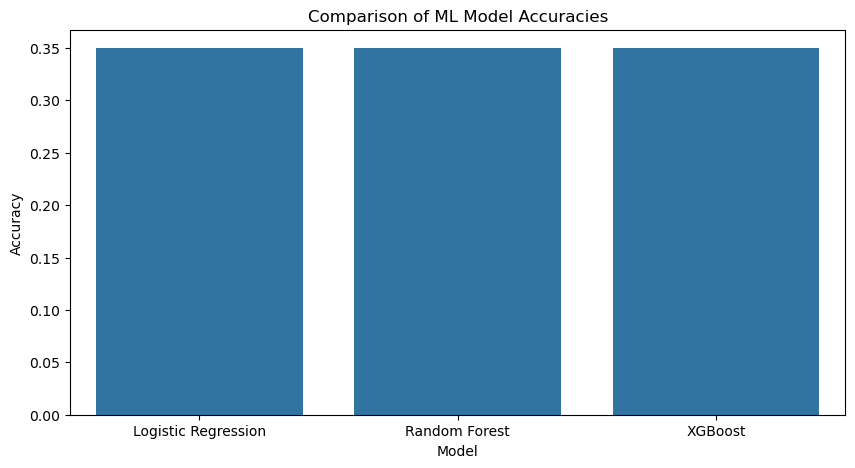

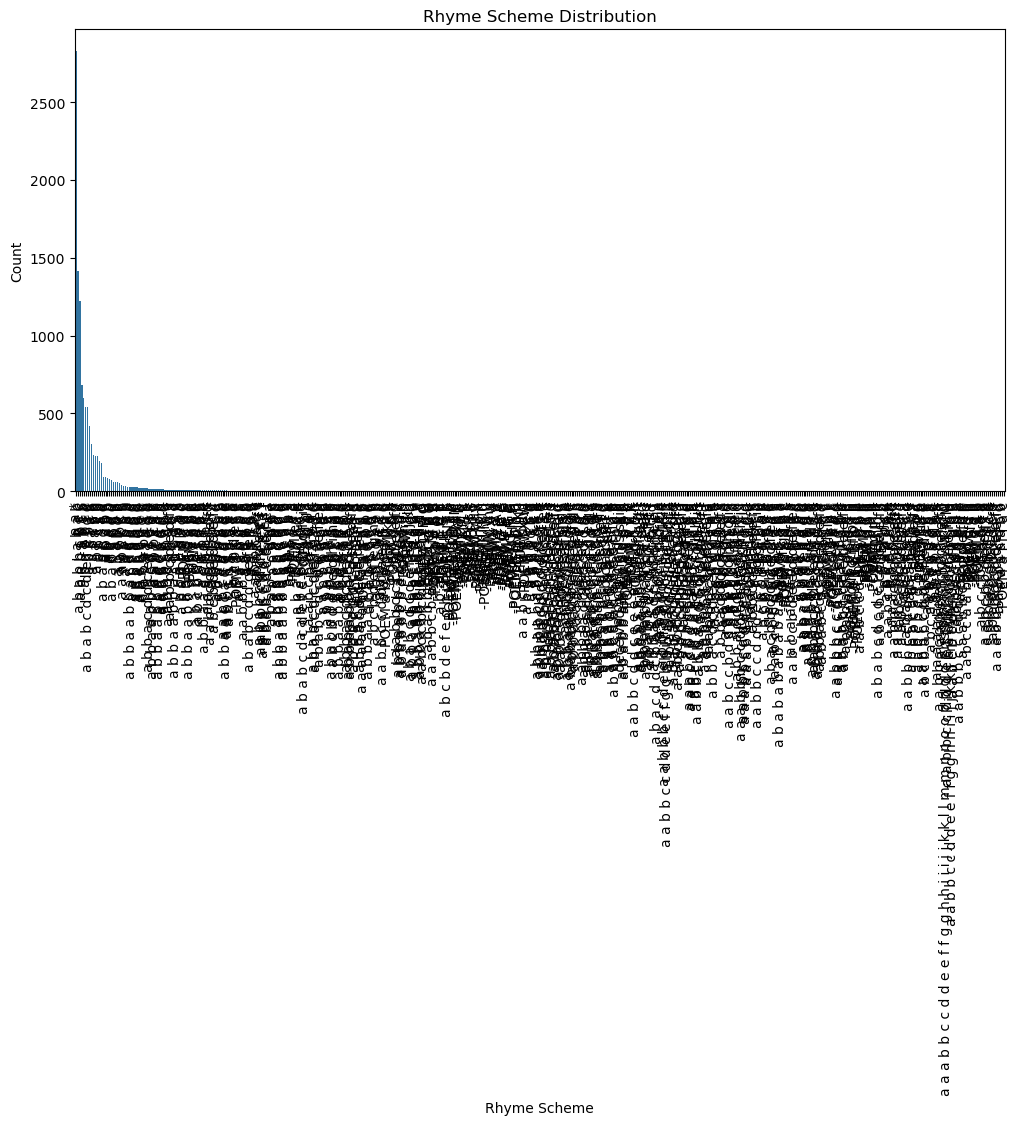

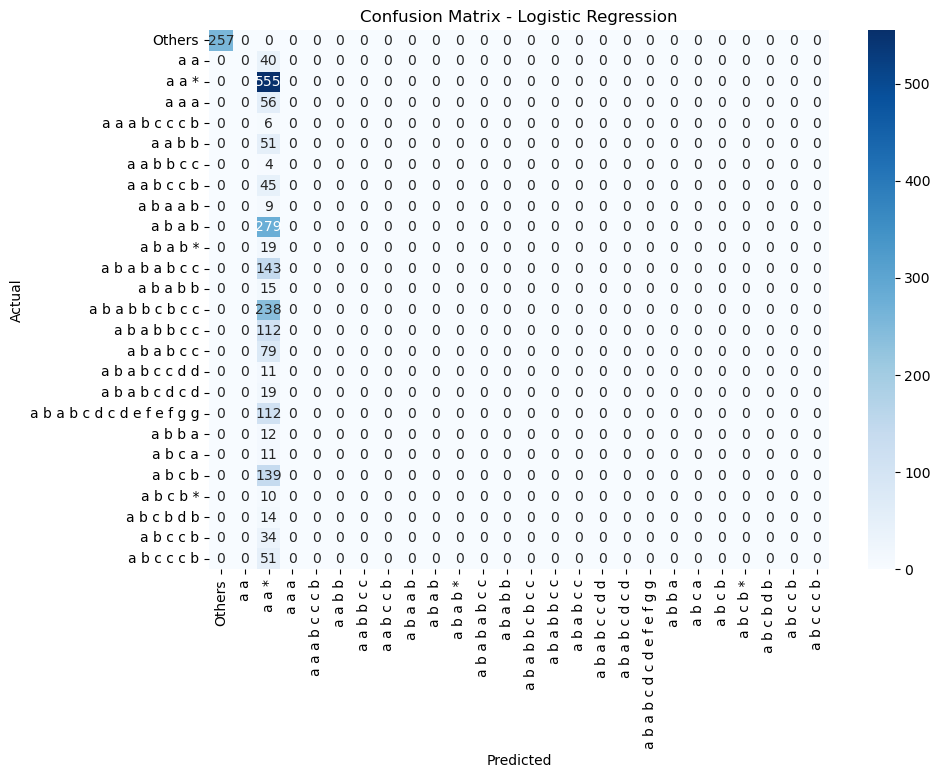

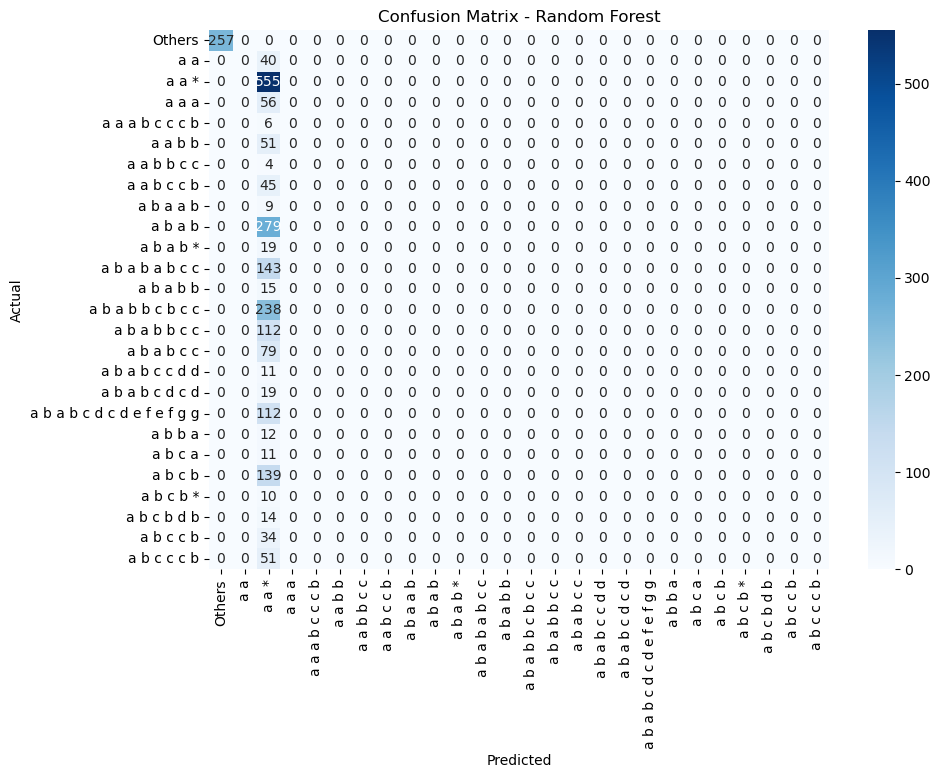

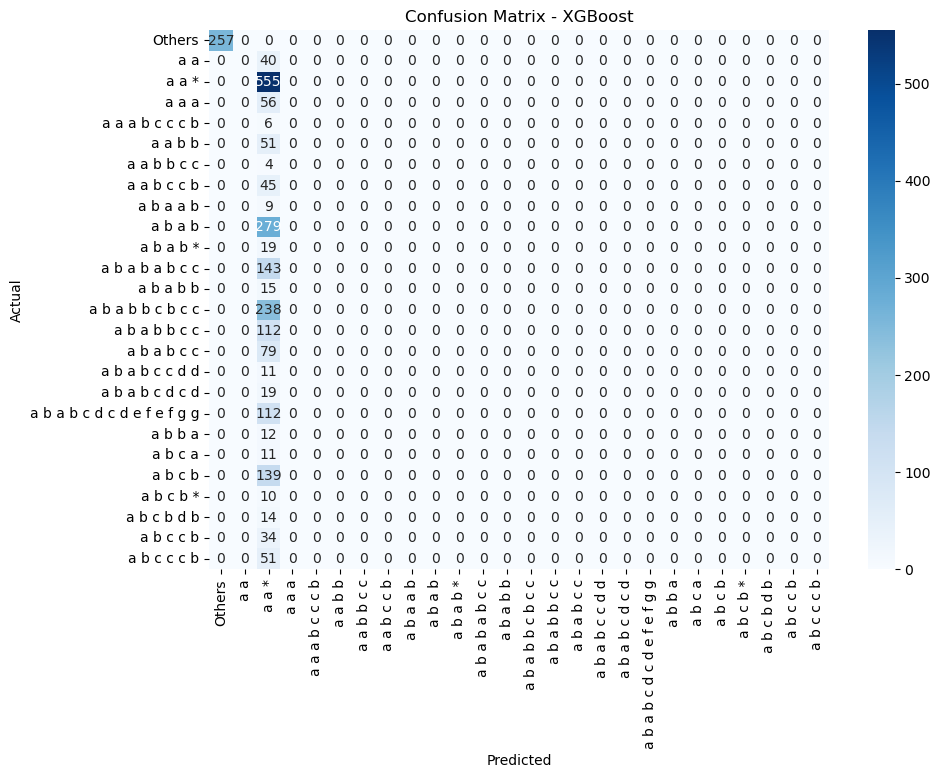

In [226]:
from sklearn.metrics import confusion_matrix

# Compare accuracy of models
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Model Accuracies")
plt.show()

# Plot bar graph for rhyme scheme distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=rhyme_counts.index, y=rhyme_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Rhyme Scheme")
plt.ylabel("Count")
plt.title("Rhyme Scheme Distribution")
plt.show()

# Calculate confusion matrices for all models
conf_matrices = {
    "Logistic Regression": confusion_matrix(y_test4, models["Logistic Regression"].predict(X_test4)),
    "Random Forest": confusion_matrix(y_test4, models["Random Forest"].predict(X_test4)),
    "XGBoost": confusion_matrix(y_test4, models["XGBoost"].predict(X_test4))
}

# Plot confusion matrices for all models
for name, conf_matrix in conf_matrices.items():
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


In [228]:
import os
print(os.listdir("english_raw"))  # Check if the folder has files


['brooke.txt', 'byron.txt', 'chesterton.txt', 'coleridge.txt', 'constable.txt', 'crosland.txt', 'daniel.txt', 'drayton.txt', 'dryden.txt', 'finch.txt', 'fletcher.txt', 'goldsmith.txt', 'griffin.txt', 'housman.txt', 'jonson.txt', 'kipling.txt', 'lodge.txt', 'lovelace.txt', 'milton.txt', 'more.txt', 'pope.txt', 'prior.txt', 'shakespeare.txt', 'shelley.txt', 'sidney.txt', 'smith.txt', 'spenser.txt', 'swift.txt', 'thomas.txt', 'turner.txt', 'wordsworth.txt', 'wyatt.txt']



🔹 Evaluating: Rhyme Scheme Classification

Logistic Regression Average AUC for Rhyme Scheme: 0.5746
Random Forest Average AUC for Rhyme Scheme: 0.5746
XGBoost Average AUC for Rhyme Scheme: 0.5746


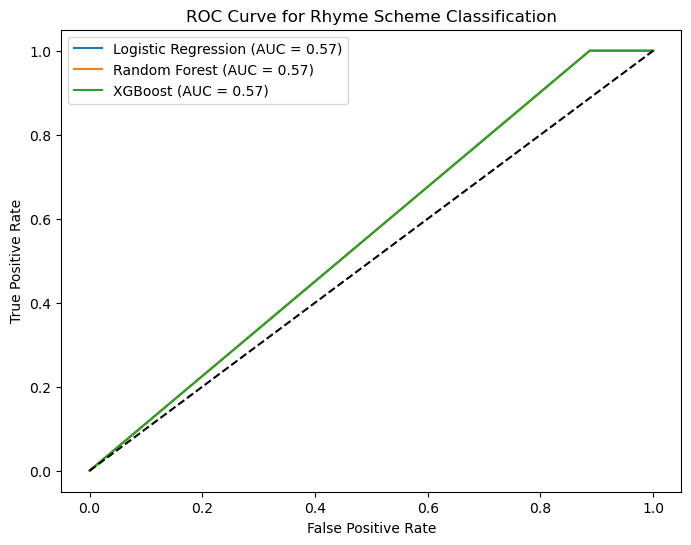

In [229]:
# Rhyme Scheme Classification
print("\n🔹 Evaluating: Rhyme Scheme Classification\n")
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_probs = model.predict_proba(X_test4)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(y_probs.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_test4 == i, y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    avg_auc = np.mean(list(roc_auc.values()))
    print(f"{name} Average AUC for Rhyme Scheme: {avg_auc:.4f}")
    plt.plot(fpr[1], tpr[1], label=f'{name} (AUC = {avg_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Rhyme Scheme Classification')
plt.legend()
plt.show()


In [ ]:
import pickle
from tensorflow.keras.models import Sequential

# ✅ Save Tokenizer
with open("tokenizer_rhyme.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


# ✅ Save LSTM Model in Keras 3 format
lstm_model.save("lstm_rhyme_model.keras")

# ✅ Save LSTM Model in H5 format (optional)
lstm_model.save("lstm_rhyme_model.h5")

print("✅ All necessary components saved successfully!")


✅ All necessary components saved successfully!


# 🎭 **Poetic Form Analysis & Detection**  

## 🔍 **Understanding Poetic Forms**  
A **poetic form** is a structured arrangement of verses, rhymes, and meters. Identifying poetic forms helps in **classifying poetry styles** and understanding the author's artistic expression.  

---

## 📚 **Common Poetic Forms & Their Structures**  

### 🔹 **1. Sonnets**  
| **Type** | **Rhyme Scheme** | **Structure** | **Example** |
|----------|----------------|--------------|-------------|
| **Shakespearean Sonnet** | ABABCDCDEFEFGG | 14 lines, iambic pentameter | "Shall I compare thee to a summer's day?" |
| **Petrarchan Sonnet** | ABBAABBACDCDCD | 14 lines, octave + sestet | Classical Italian sonnets |
| **Spenserian Sonnet** | ABABBCBCCDCDEE | 14 lines, interlocking rhyme | Edmund Spenser's works |

---

### 🔹 **2. Haikus & Tankas (Japanese Forms)**  
| **Type** | **Structure** | **Example** |
|---------|-------------|-------------|
| **Haiku** | 3 lines, 5-7-5 syllables, no rhyme | "An old silent pond / A frog jumps into the pond— / Splash! Silence again." |
| **Tanka** | 5 lines, 5-7-5-7-7 syllables | "Like falling cherry / The petals kiss the river / Drifting far away." |

---

### 🔹 **3. Ballads & Narrative Poems**  
| **Type** | **Rhyme Scheme** | **Structure** | **Example** |
|---------|----------------|--------------|-------------|
| **Ballad** | ABCB | 4-line stanzas, tells a story | "The Rime of the Ancient Mariner" |
| **Epic** | Varies | Long narrative poem | "The Iliad" & "The Odyssey" |

---

### 🔹 **4. Villanelle & Terza Rima (Complex Forms)**  
| **Type** | **Rhyme Scheme** | **Structure** | **Example** |
|---------|----------------|--------------|-------------|
| **Villanelle** | ABA ABA ABA ABA ABA ABAA | 19 lines, repeated refrains | "Do Not Go Gentle into That Good Night" |
| **Terza Rima** | ABA BCB CDC DED... | Interlocking 3-line stanzas | "Divine Comedy" |

---

### 🔹 **5. Limericks & Odes**  
| **Type** | **Rhyme Scheme** | **Structure** | **Example** |
|---------|----------------|--------------|-------------|
| **Limerick** | AABBA | 5 lines, humorous tone | "There once was a man from Peru..." |
| **Ode** | Varies | Dedicated to a subject, lyrical | "Ode to a Nightingale" |

---

### 🔹 **6. Free Verse & Experimental Forms**  
| **Type** | **Rhyme Scheme** | **Structure** | **Example** |
|---------|----------------|--------------|-------------|
| **Free Verse** | No fixed rhyme | No set pattern | Walt Whitman, Allen Ginsberg |
| **Concrete Poetry** | Visual shape-based structure | Forms an image | "A Mouse's Tail" by Lewis Carroll |

---

## 🔬 **Poetic Form Detection Models**  
Since **poetic form detection** involves **classification and pattern recognition**, we will use:  

- ✅ **Traditional Machine Learning (ML)**  
  - Logistic Regression  
  - Random Forest  
  - XGBoost  
- ✅ **Deep Learning**  
  - Long Short-Term Memory (LSTM) Networks  
  - Transformer-based Models (BERT, GPT)  

---

## 📊 **Training & Evaluation Metrics**  
To measure the accuracy of **Poetic Form Classification**, we will use:  
- **Precision & Recall**: Evaluates classification accuracy.  
- **F1-Score**: Balances precision and recall.  
- **Accuracy**: Measures overall correctness.  

---

In [210]:
""" import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Load dataset
file_path = "poem_features_with_filled_forms.csv"
df = pd.read_csv(file_path)

# Encode labels
label_encoder = LabelEncoder()
df['PoeticForm_encoded'] = label_encoder.fit_transform(df['PoeticForm'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df['content'], df['PoeticForm_encoded'], test_size=0.2, random_state=42)

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True)

# Create Hugging Face dataset
dataset = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})
dataset = dataset.map(tokenize_function, batched=True)

test_dataset = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.tolist()})
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Load pre-trained BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.classes_))

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir="./logs",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=test_dataset,
)

# Train model
trainer.train()

# Evaluate model
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

# Print accuracy
from sklearn.metrics import accuracy_score, classification_report
print("BERT Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=label_encoder.classes_))
 """

' import pandas as pd\nimport numpy as np\nimport torch\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import LabelEncoder\nfrom transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments\nfrom datasets import Dataset\n\n# Load dataset\nfile_path = "poem_features_with_filled_forms.csv"\ndf = pd.read_csv(file_path)\n\n# Encode labels\nlabel_encoder = LabelEncoder()\ndf[\'PoeticForm_encoded\'] = label_encoder.fit_transform(df[\'PoeticForm\'])\n\n# Train-test split\nX_train, X_test, y_train, y_test = train_test_split(df[\'content\'], df[\'PoeticForm_encoded\'], test_size=0.2, random_state=42)\n\n# Load BERT tokenizer\ntokenizer = BertTokenizer.from_pretrained(\'bert-base-uncased\')\n\ndef tokenize_function(examples):\n    return tokenizer(examples[\'text\'], padding=\'max_length\', truncation=True)\n\n# Create Hugging Face dataset\ndataset = Dataset.from_dict({"text": X_train.tolist(), "label": y_train.tolist()})\ndatase

In [232]:
#Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder


In [239]:

# Load dataset
df = pd.read_csv("poem_features_with_filled_forms.csv")

# Define features and labels
X = df["content"]
y = df["PoeticForm"]



In [240]:
# Encode labels
label_encoder4 = LabelEncoder()
y_encoded1 = label_encoder4.fit_transform(y)

# Balance test set
unique_classes = y.unique()
min_samples = min(y.value_counts())
min_samples = max(min_samples, 70)  # Increase test data size slightly

balanced_test_df = pd.concat([df[y == label].sample(min(len(df[y == label]), min_samples), random_state=42) for label in unique_classes])
X_test_balanced1 = balanced_test_df["content"]
y_test_balanced1 = balanced_test_df["PoeticForm"]
y_test_balanced_encoded = label_encoder4.transform(y_test_balanced1)


In [241]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming X and y_encoded are already defined
X_train5, _, y_train5, _ = train_test_split(X, y_encoded1, test_size=0.2, stratify=y_encoded1, random_state=42)

# Convert text to TF-IDF vectors
vectorizer4 = TfidfVectorizer(max_features=5000)
X_train_tfidf4 = vectorizer4.fit_transform(X_train5)




Logistic Regression:
              precision    recall  f1-score   support

  Free Verse       0.00      0.00      0.00        14
       Haiku       0.94      0.76      0.84        59
    Limerick       0.64      0.99      0.78        70
      Sonnet       0.98      0.80      0.88        70

    accuracy                           0.80       213
   macro avg       0.64      0.64      0.62       213
weighted avg       0.79      0.80      0.78       213



c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


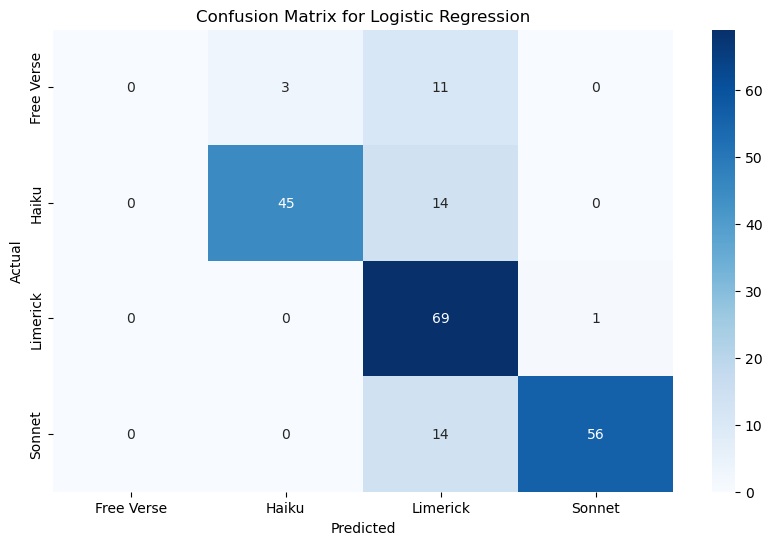


Random Forest:
              precision    recall  f1-score   support

  Free Verse       0.92      0.79      0.85        14
       Haiku       0.98      0.93      0.96        59
    Limerick       0.82      1.00      0.90        70
      Sonnet       1.00      0.86      0.92        70

    accuracy                           0.92       213
   macro avg       0.93      0.89      0.91       213
weighted avg       0.93      0.92      0.92       213



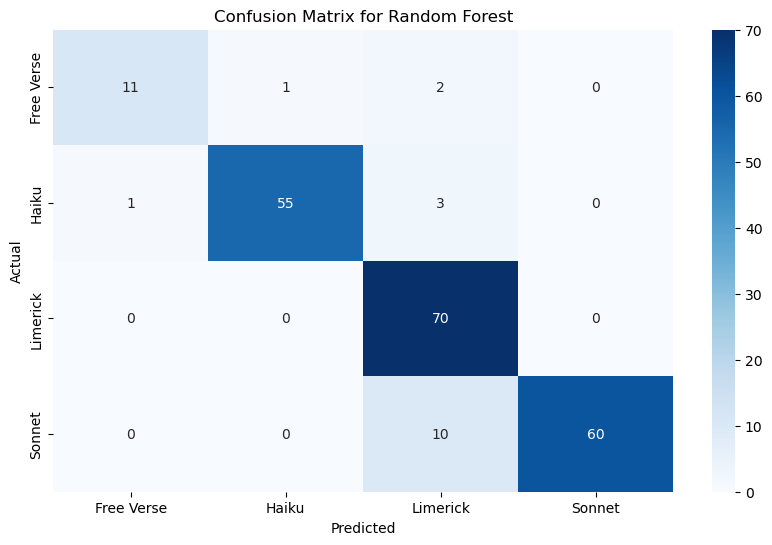

c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:43:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost:
              precision    recall  f1-score   support

  Free Verse       0.92      0.79      0.85        14
       Haiku       0.98      0.93      0.96        59
    Limerick       0.86      1.00      0.93        70
      Sonnet       1.00      0.91      0.96        70

    accuracy                           0.94       213
   macro avg       0.94      0.91      0.92       213
weighted avg       0.94      0.94      0.94       213



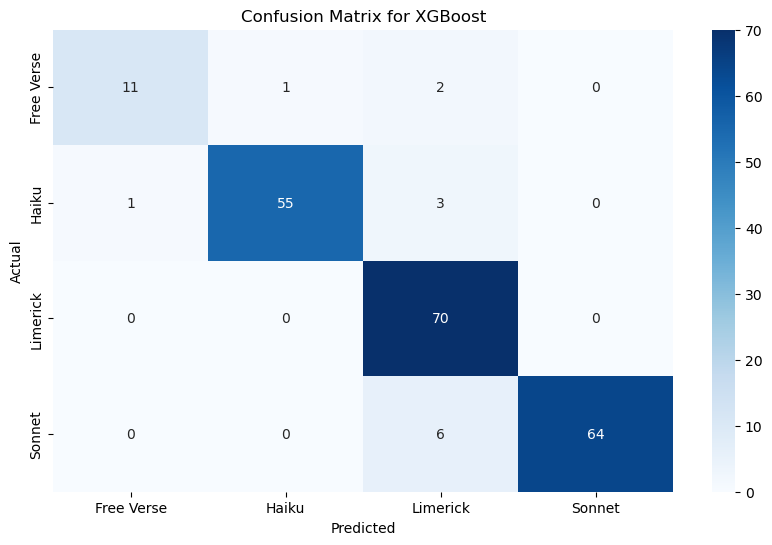

In [242]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Transform the test data using the loaded vectorizer
X_test_tfidf4 = vectorizer4.transform(X_test_balanced1)

# Train Traditional ML Models
def train_ml_model(model, X_train5, y_train5, X_test5, y_test5, model_name):
    model.fit(X_train5, y_train5)
    y_pred = model.predict(X_test5)
    
    print(f"\n{model_name}:")
    print(classification_report(y_test5, y_pred, target_names=label_encoder4.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test5, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder4.classes_, yticklabels=label_encoder4.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()
    
    return model.score(X_test5, y_test5)

# Train Models (without saving)
model_accuracies = {}
model_accuracies["Logistic Regression"] = train_ml_model(LogisticRegression(max_iter=1000), X_train_tfidf4, y_train5, X_test_tfidf4, y_test_balanced_encoded, "Logistic Regression")
model_accuracies["Random Forest"] = train_ml_model(RandomForestClassifier(n_estimators=100), X_train_tfidf4, y_train5, X_test_tfidf4, y_test_balanced_encoded, "Random Forest")
model_accuracies["XGBoost"] = train_ml_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), X_train_tfidf4, y_train5, X_test_tfidf4, y_test_balanced_encoded, "XGBoost")


In [243]:
# Tokenization for LSTM
max_words = 10000
max_len = 200
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train5)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train5), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_balanced1), maxlen=max_len)

# Build LSTM Model
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),
    Dense(len(label_encoder4.classes_), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train LSTM
model.fit(X_train_seq, y_train5, epochs=5, batch_size=32, validation_data=(X_test_seq, y_test_balanced_encoded))

# Evaluate LSTM
y_pred_lstm = model.predict(X_test_seq).argmax(axis=1)
print("\nLSTM:")
print(classification_report(y_test_balanced_encoded, y_pred_lstm, target_names=label_encoder4.classes_))



c:\Users\Rahul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.4312 - loss: 1.3469 - val_accuracy: 0.4742 - val_loss: 1.2897
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5923 - loss: 0.9324 - val_accuracy: 0.5634 - val_loss: 0.8141
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6414 - loss: 0.7546 - val_accuracy: 0.5634 - val_loss: 0.8867
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6470 - loss: 0.6988 - val_accuracy: 0.5915 - val_loss: 0.7094
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6822 - loss: 0.6225 - val_accuracy: 0.7887 - val_loss: 0.6695
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

LSTM:
              precision    recall  f1-score   support

  Free Verse       0.00      0.00      0.00        14
       Haiku       0.85      0.98      0.91        59
    Limerick       0.68      0.99      0.80        70
      Sonnet       0.95      0.59      0.73        70

    accuracy                           0.79       213

c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


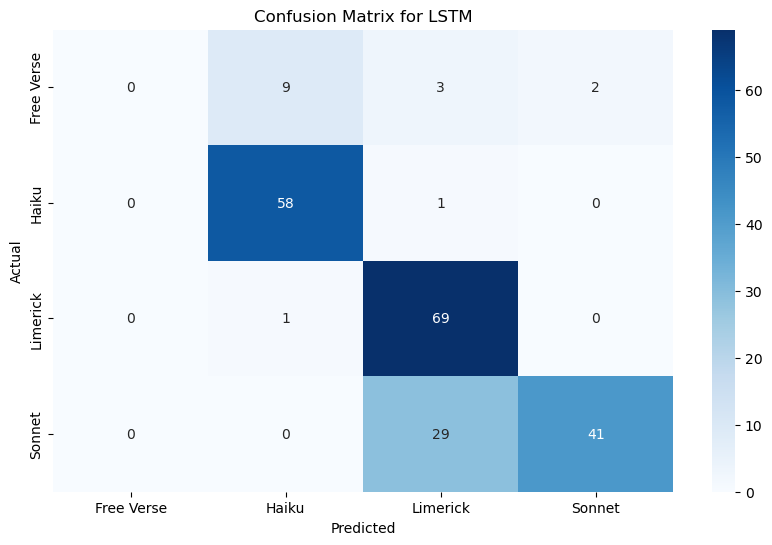


LSTM Classification Report:

              precision    recall  f1-score   support

  Free Verse       0.00      0.00      0.00        14
       Haiku       0.85      0.98      0.91        59
    Limerick       0.68      0.99      0.80        70
      Sonnet       0.95      0.59      0.73        70

    accuracy                           0.79       213
   macro avg       0.62      0.64      0.61       213
weighted avg       0.77      0.79      0.76       213



c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [244]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ✅ Convert Predictions to Encoded Labels
y_pred_lstm = np.argmax(model.predict(X_test_seq), axis=1)

# ✅ Plot Confusion Matrix
cm = confusion_matrix(y_test_balanced_encoded, y_pred_lstm)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder4.classes_, yticklabels=label_encoder4.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for LSTM")
plt.show()

# ✅ Print Classification Report
print("\nLSTM Classification Report:\n")
print(classification_report(y_test_balanced_encoded, y_pred_lstm, target_names=label_encoder4.classes_))


In [245]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(n_estimators=100)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

rf_cv_scores = cross_val_score(rf_model, X_train_tfidf4, y_train5, cv=5)
xgb_cv_scores = cross_val_score(xgb_model, X_train_tfidf4, y_train5, cv=5)

print("Random Forest CV Accuracy:", np.mean(rf_cv_scores), "±", np.std(rf_cv_scores))
print("XGBoost CV Accuracy:", np.mean(xgb_cv_scores), "±", np.std(xgb_cv_scores))


c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:43:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:43:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:43:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Rahul\anaconda3\Lib\site-packages\

Random Forest CV Accuracy: 0.74 ± 0.02150581316760657
XGBoost CV Accuracy: 0.7525000000000001 ± 0.03102418411497713


In [246]:
import pickle
with open("vectorizer_poetic_form.pkl", "wb") as f:
    pickle.dump(vectorizer4, f)
print("✅ TF-IDF Vectorizer saved successfully!")
with open("xgboost_poetic_form.pkl", "wb") as f:
    pickle.dump(models["XGBoost"], f)
print("✅ XGBoost Model saved successfully!")
with open("label_encoder_poetic_form.pkl", "wb") as f:
    pickle.dump(label_encoder4, f)
print("✅ Label Encoder saved successfully!")

print("TF-IDF Feature Count:", len(vectorizer4.get_feature_names_out()))
print("Vocabulary Sample:", list(vectorizer4.vocabulary_.keys())[:20])


✅ TF-IDF Vectorizer saved successfully!
✅ XGBoost Model saved successfully!
✅ Label Encoder saved successfully!
TF-IDF Feature Count: 5000
Vocabulary Sample: ['kind', 'are', 'her', 'answers', 'but', 'keeps', 'no', 'day', 'breaks', 'time', 'as', 'from', 'their', 'own', 'music', 'when', 'they', 'stray', 'all', 'free']


🔍 TF-IDF Feature Count: 5000
🔍 Sample Vocabulary: ['kind', 'are', 'her', 'answers', 'but', 'keeps', 'no', 'day', 'breaks', 'time', 'as', 'from', 'their', 'own', 'music', 'when', 'they', 'stray', 'all', 'free']

📊 Logistic Regression Classification Report:
              precision    recall  f1-score   support

  Free Verse       0.00      0.00      0.00        14
       Haiku       0.94      0.76      0.84        59
    Limerick       0.64      0.99      0.78        70
      Sonnet       0.98      0.80      0.88        70

    accuracy                           0.80       213
   macro avg       0.64      0.64      0.62       213
weighted avg       0.79      0.80      0.78       213



c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


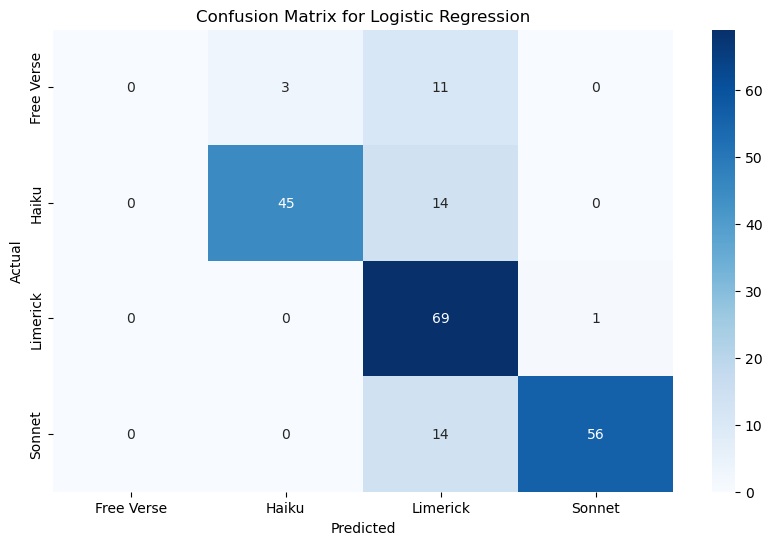

✅ Logistic Regression saved successfully as logistic_regression.pkl!

📊 Random Forest Classification Report:
              precision    recall  f1-score   support

  Free Verse       0.92      0.79      0.85        14
       Haiku       0.98      0.93      0.96        59
    Limerick       0.83      1.00      0.91        70
      Sonnet       1.00      0.87      0.93        70

    accuracy                           0.92       213
   macro avg       0.93      0.90      0.91       213
weighted avg       0.93      0.92      0.93       213



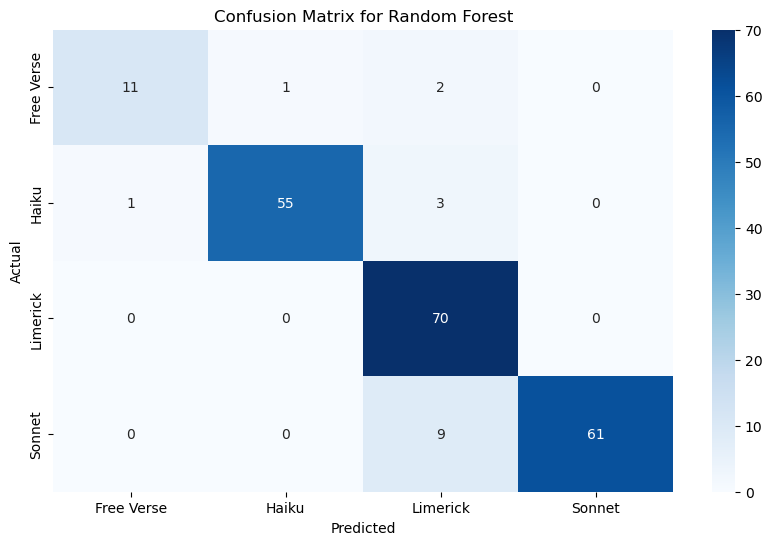

✅ Random Forest saved successfully as random_forest.pkl!


c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:49:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 XGBoost Classification Report:
              precision    recall  f1-score   support

  Free Verse       0.92      0.79      0.85        14
       Haiku       0.98      0.93      0.96        59
    Limerick       0.86      1.00      0.93        70
      Sonnet       1.00      0.91      0.96        70

    accuracy                           0.94       213
   macro avg       0.94      0.91      0.92       213
weighted avg       0.94      0.94      0.94       213



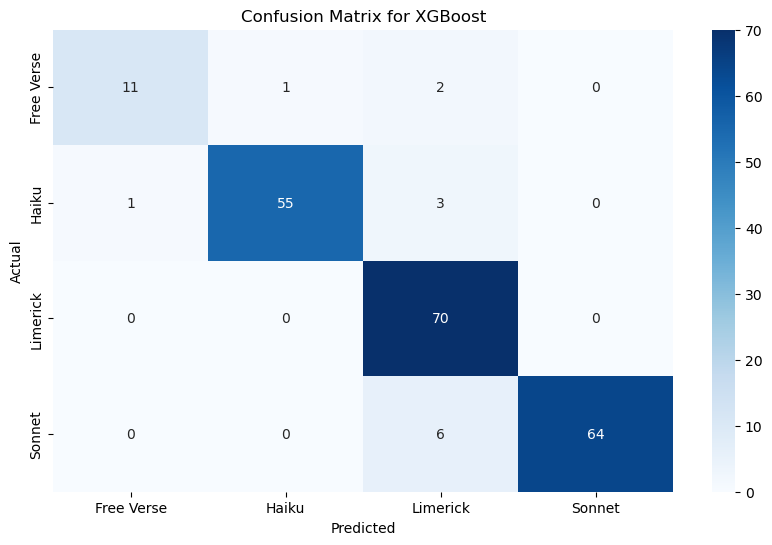

✅ XGBoost saved successfully as xgboost_poetic_form.pkl!
Epoch 1/5


c:\Users\Rahul\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.4649 - loss: 1.3338 - val_accuracy: 0.5775 - val_loss: 1.0877
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5789 - loss: 0.8807 - val_accuracy: 0.5775 - val_loss: 0.8484
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6515 - loss: 0.7364 - val_accuracy: 0.5822 - val_loss: 0.7283
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6152 - loss: 0.7061 - val_accuracy: 0.5869 - val_loss: 0.7584
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6401 - loss: 0.6679 - val_accuracy: 0.6714 - val_loss: 0.6513
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

📊 LSTM Classification Report:
              precision    recall  f1-score   support

  Free Verse       0.00      0.00      0.00        14
       Haiku       0.83      0.98      0.90        59
    Limerick       0.54      0.99      0.70        70
      Sonnet       1.00      0.23      0.37        70

    accuracy                           

c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


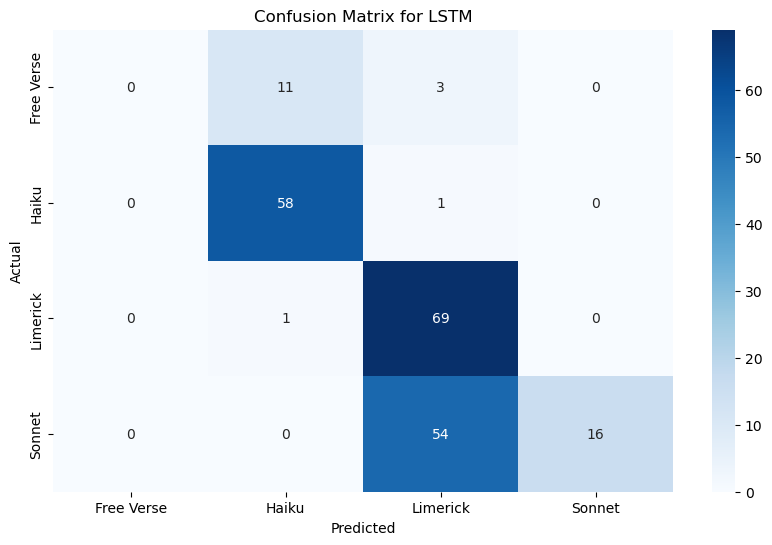

c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:49:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:49:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Rahul\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:49:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Rahul\anaconda3\Lib\site-packages\


📊 Cross-Validation Results:
✅ Random Forest CV Accuracy: 0.7424999999999999 ± 0.01695582495781315
✅ XGBoost CV Accuracy: 0.7525000000000001 ± 0.03102418411497713
✅ TF-IDF Vectorizer saved successfully!
✅ Label Encoder saved successfully!

🔍 Feature Mismatch Check:
🔹 TF-IDF Features: 5000
🔹 XGBoost Expected Features: 5000

✅ All models and vectorizers saved successfully!


In [247]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ✅ Load Dataset
df = pd.read_csv("poem_features_with_filled_forms.csv")

# ✅ Define Features & Labels
X = df["content"]
y = df["PoeticForm"]

# ✅ Encode Labels
label_encoder4 = LabelEncoder()
y_encoded1 = label_encoder4.fit_transform(y)

# ✅ Balance Test Set
unique_classes = y.unique()
min_samples = min(y.value_counts())
min_samples = max(min_samples, 70)

balanced_test_df = pd.concat([
    df[y == label].sample(min(len(df[y == label]), min_samples), random_state=42) 
    for label in unique_classes
])
X_test_balanced1 = balanced_test_df["content"]
y_test_balanced1 = balanced_test_df["PoeticForm"]
y_test_balanced_encoded = label_encoder4.transform(y_test_balanced1)

# ✅ Train-Test Split
X_train5, _, y_train5, _ = train_test_split(X, y_encoded1, test_size=0.2, stratify=y_encoded1, random_state=42)

# ✅ Convert Text to TF-IDF Vectors
vectorizer4 = TfidfVectorizer(max_features=5000)
X_train_tfidf4 = vectorizer4.fit_transform(X_train5)
X_test_tfidf4 = vectorizer4.transform(X_test_balanced1)

# ✅ Print Feature Count for Debugging
print(f"🔍 TF-IDF Feature Count: {X_train_tfidf4.shape[1]}")
print(f"🔍 Sample Vocabulary: {list(vectorizer4.vocabulary_.keys())[:20]}")

# ✅ Train Traditional ML Models
def train_ml_model(model, X_train, y_train, X_test, y_test, model_name, filename):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n📊 {model_name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder4.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder4.classes_, yticklabels=label_encoder4.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

    # ✅ Save Model to Pickle
    with open(filename, "wb") as f:
        pickle.dump(model, f)
    print(f"✅ {model_name} saved successfully as {filename}!")

    return model

# ✅ Train & Save Models
models = {}
models["Logistic Regression"] = train_ml_model(LogisticRegression(max_iter=1000), X_train_tfidf4, y_train5, X_test_tfidf4, y_test_balanced_encoded, "Logistic Regression", "logistic_regression.pkl")
models["Random Forest"] = train_ml_model(RandomForestClassifier(n_estimators=100), X_train_tfidf4, y_train5, X_test_tfidf4, y_test_balanced_encoded, "Random Forest", "random_forest.pkl")
models["XGBoost"] = train_ml_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), X_train_tfidf4, y_train5, X_test_tfidf4, y_test_balanced_encoded, "XGBoost", "xgboost_poetic_form.pkl")

# ✅ Tokenization for LSTM
max_words = 10000
max_len = 200
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train5)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train5), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_balanced1), maxlen=max_len)

# ✅ Build LSTM Model
model_lstm = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),
    Dense(len(label_encoder4.classes_), activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# ✅ Train LSTM
model_lstm.fit(X_train_seq, y_train5, epochs=5, batch_size=32, validation_data=(X_test_seq, y_test_balanced_encoded))

# ✅ Evaluate LSTM
y_pred_lstm = model_lstm.predict(X_test_seq).argmax(axis=1)
print("\n📊 LSTM Classification Report:")
print(classification_report(y_test_balanced_encoded, y_pred_lstm, target_names=label_encoder4.classes_))

# ✅ Save LSTM Model
model_lstm.save("lstm_poetic_form.keras")
print("✅ LSTM Model saved successfully!")

# ✅ Plot Confusion Matrix for LSTM
cm = confusion_matrix(y_test_balanced_encoded, y_pred_lstm)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder4.classes_, yticklabels=label_encoder4.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for LSTM")
plt.show()

# ✅ Cross-Validation
rf_model = RandomForestClassifier(n_estimators=100)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

rf_cv_scores = cross_val_score(rf_model, X_train_tfidf4, y_train5, cv=5)
xgb_cv_scores = cross_val_score(xgb_model, X_train_tfidf4, y_train5, cv=5)

print("\n📊 Cross-Validation Results:")
print("✅ Random Forest CV Accuracy:", np.mean(rf_cv_scores), "±", np.std(rf_cv_scores))
print("✅ XGBoost CV Accuracy:", np.mean(xgb_cv_scores), "±", np.std(xgb_cv_scores))

# ✅ Save Vectorizer & Label Encoder
with open("vectorizer_poetic_form.pkl", "wb") as f:
    pickle.dump(vectorizer4, f)
print("✅ TF-IDF Vectorizer saved successfully!")

with open("label_encoder_poetic_form.pkl", "wb") as f:
    pickle.dump(label_encoder4, f)
print("✅ Label Encoder saved successfully!")

# ✅ Print Feature Mismatch Check
xgb_model_test = pickle.load(open("xgboost_poetic_form.pkl", "rb"))
vectorizer_features = len(vectorizer4.get_feature_names_out())
model_features = xgb_model_test.n_features_in_

print(f"\n🔍 Feature Mismatch Check:")
print(f"🔹 TF-IDF Features: {vectorizer_features}")
print(f"🔹 XGBoost Expected Features: {model_features}")

if vectorizer_features != model_features:
    print("🚨 Feature Mismatch Detected! Retrain XGBoost using the correct vectorizer.")

print("\n✅ All models and vectorizers saved successfully!")
